### Import Libraries

In [110]:
import os 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import pickle
from pickle import dump
import json 

from sklearn.metrics import f1_score

from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.preprocessing import LabelEncoder 

from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from xgboost import XGBClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.cluster import KMeans 

from sklearn.base import BaseEstimator, TransformerMixin 
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

### Load the Dataset

In [113]:
# Load training dataset
df_train = pd.read_csv('abandono_train.csv', index_col=0)
df_train.reset_index(inplace=True)
df_train

,train_idx,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag
0,0,713071383,54,F,1,Unknown,Single,Unknown,Blue,36,...,3,3723.0,1728,1995.0,0.595,8554,99,0.678,0.464,1
1,1,714246333,58,F,4,High School,Married,Unknown,Blue,48,...,3,5396.0,1803,3593.0,0.493,2107,39,0.393,0.334,0
2,2,718206783,45,F,4,Unknown,Single,Less than $40K,Gold,36,...,3,15987.0,1648,14339.0,0.732,1436,36,1.250,0.103,1
3,3,721096983,34,F,2,Graduate,Single,Less than $40K,Blue,36,...,4,3625.0,2517,1108.0,1.158,2616,46,1.300,0.694,1
4,4,720028683,49,F,2,High School,Married,$40K - $60K,Blue,39,...,4,2720.0,1926,794.0,0.602,3806,61,0.794,0.708,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8096,8096,769053033,44,F,1,Graduate,Single,$40K - $60K,Blue,38,...,5,4142.0,2517,1625.0,0.809,2104,44,0.833,0.608,0
8097,8097,714406158,53,F,3,High School,Divorced,Unknown,Blue,36,...,6,7939.0,0,7939.0,0.551,2269,42,0.312,0.000,0
8098,8098,714140133,42,F,4,Graduate,Unknown,Less than $40K,Blue,32,...,2,2314.0,1547,767.0,0.804,4678,74,1.000,0.669,1
8099,8099,720244983,40,M,3,Unknown,Single,$40K - $60K,Blue,28,...,1,3563.0,1707,1856.0,0.506,1482,42,0.312,0.479,1


In [114]:
df_train.shape

(8101, 22)

In [115]:
# Load test dataset
df_test = pd.read_csv('abandono_test.csv', index_col=0)
df_test.reset_index(inplace=True)
df_test

,test_idx,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,719455083,48,F,3,Uneducated,Single,Less than $40K,Blue,39,...,3,4,2991.0,1508,1483.0,0.703,3734,64,0.882,0.504
1,1,773503308,59,M,1,Uneducated,Single,Less than $40K,Blue,53,...,5,4,2192.0,1569,623.0,0.706,4010,79,0.717,0.716
2,2,715452408,37,F,2,Graduate,Divorced,Less than $40K,Blue,36,...,3,3,1734.0,987,747.0,0.879,4727,67,0.914,0.569
3,3,711264033,47,M,3,Doctorate,Divorced,$40K - $60K,Blue,36,...,2,3,4786.0,1516,3270.0,0.940,4973,74,0.850,0.317
4,4,718943508,42,M,3,Unknown,Single,$80K - $120K,Blue,33,...,3,2,3714.0,2170,1544.0,0.524,1454,35,0.522,0.584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,2021,814776033,34,M,2,Graduate,Single,$80K - $120K,Blue,29,...,1,3,13395.0,1678,11717.0,1.006,2650,69,0.865,0.125
2022,2022,720444408,35,F,1,College,Single,Less than $40K,Blue,25,...,2,4,2231.0,1791,440.0,0.820,2576,42,0.750,0.803
2023,2023,720503508,44,F,1,Uneducated,Divorced,Less than $40K,Blue,37,...,2,3,5594.0,1235,4359.0,0.549,5220,75,0.829,0.221
2024,2024,721217283,27,M,0,Graduate,Single,$120K +,Blue,17,...,2,2,8713.0,1354,7359.0,0.558,2094,36,0.333,0.155


In [116]:
df_test.shape

(2026, 21)

### Features

test_idx: Unique identifier for each data record.

CLIENTNUM: Unique identifier for each bank customer.

Customer_Age: Age of the customer in years.

Gender: Customer’s gender.

Dependent_count: Number of dependents the customer has.

Education_Level: Customer’s level of education.

Marital_Status: Customer’s marital status.

Income_Category: Income range of the customer.

Card_Category: Type of credit card held by the customer.

Months_on_book: Number of months the customer has been with the bank.

Months_Inactive_12_mon: Number of months the customer has been inactive in the last 12 months.

Contacts_Count_12_mon: Number of times the customer has contacted the bank in the last 12 months.

Credit_Limit: Credit limit assigned to the customer.

Total_Revolving_Bal: Total revolving balance on the customer’s credit card(s).

Avg_Open_To_Buy: Average available credit to the customer.

Total_Amt_Chng_Q4_Q1: Percentage change in the total transaction amount between the last quarter and the previous quarter.

Total_Trans_Amt: Total transaction amount made by the customer.

Total_Trans_Ct: Total number of transactions made by the customer.

Total_Ct_Chng_Q4_Q1: Percentage change in the number of transactions between the last quarter and the previous quarter.

Avg_Utilization_Ratio: Average utilization ratio of the credit used compared to the available credit.

Attrition_Flag: This variable indicates whether the customer has closed their account or is still an active customer.

### Exploratory Data Analysis (EDA)

In [117]:
# Descriptive Statistics
def data_report(df):

    # General information
    print("General information:\n")
    print(df.info())
    print("\n")

    # Statistical summary
    print("Statistical summary:\n")
    print(df.describe())
    print("\n")

    # Null values
    print("Null values:\n")
    print(df.isnull().sum())
    print("\n")

    # Unique values per column
    print("Unique values:\n")
    for col in df.columns:
        print(col, ":", df[col].nunique())
    print("\n")

    # Duplicate values
    print("Duplicate values:\n")
    print(df.duplicated().sum())
    print("\n")

    # Distribution of categorical variables
    print("Categorical variables distribution:\n")
    for col in df.select_dtypes(include=["str"]).columns:
        print(col, ":\n", df[col].value_counts(normalize=True), "\n")

data_report(df_train)

General information:

<class 'pandas.DataFrame'>
RangeIndex: 8101 entries, 0 to 8100
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   train_idx                 8101 non-null   int64  
 1   CLIENTNUM                 8101 non-null   int64  
 2   Customer_Age              8101 non-null   int64  
 3   Gender                    8101 non-null   str    
 4   Dependent_count           8101 non-null   int64  
 5   Education_Level           8101 non-null   str    
 6   Marital_Status            8101 non-null   str    
 7   Income_Category           8101 non-null   str    
 8   Card_Category             8101 non-null   str    
 9   Months_on_book            8101 non-null   int64  
 10  Total_Relationship_Count  8101 non-null   int64  
 11  Months_Inactive_12_mon    8101 non-null   int64  
 12  Contacts_Count_12_mon     8101 non-null   int64  
 13  Credit_Limit              8101 non-null   float64
 1

In [118]:
data_report(df_test)

General information:

<class 'pandas.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   test_idx                  2026 non-null   int64  
 1   CLIENTNUM                 2026 non-null   int64  
 2   Customer_Age              2026 non-null   int64  
 3   Gender                    2026 non-null   str    
 4   Dependent_count           2026 non-null   int64  
 5   Education_Level           2026 non-null   str    
 6   Marital_Status            2026 non-null   str    
 7   Income_Category           2026 non-null   str    
 8   Card_Category             2026 non-null   str    
 9   Months_on_book            2026 non-null   int64  
 10  Total_Relationship_Count  2026 non-null   int64  
 11  Months_Inactive_12_mon    2026 non-null   int64  
 12  Contacts_Count_12_mon     2026 non-null   int64  
 13  Credit_Limit              2026 non-null   float64
 1

In [119]:
# Separate variables by type

target = df_train.columns[-1]

def get_list_of_vars(dataset, target):
    id_vars = []
    num = []
    binary = []
    cat = []

    for col in dataset.columns:
        n_unique = dataset[col].nunique()
        dtype = dataset[col].dtype

        # ID-like variables (almost unique per row)
        if (dtype.kind in 'i') and (n_unique > dataset.shape[0] * 0.9):
            id_vars.append(col)

        # Numerical variables
        elif (dtype.kind in ['i', 'f']) and (col != target) and (n_unique != 2) and (n_unique <= dataset.shape[0] * 0.9):
            num.append(col)

        # Binary variables
        elif (col != target) and (n_unique == 2):
            binary.append(col)

        # Categorical variables
        elif (dtype.kind == 'O') and (col != target):
            cat.append(col)

    return id_vars, num, binary, cat

In [120]:
print("This is the target variable:")
print(target)


id_vars, num, binary, cat = get_list_of_vars(df_train, target)

print("\nSummary of variable types:")
print(f"ID variables: {len(id_vars)}")
print(f"Numerical variables: {len(num)}")
print(f"Binary variables: {len(binary)}")
print(f"Categorical variables: {len(cat)}")
print(f"Total columns: {df_train.shape[1]}")

This is the target variable:
Attrition_Flag

Summary of variable types:
ID variables: 2
Numerical variables: 14
Binary variables: 1
Categorical variables: 4
Total columns: 22


In [121]:
# Class for EDA visualization
class EDA:
    def __init__(self, df, num, cat, binary, target):
        self.df = df
        self.num = num
        self.cat = cat
        self.binary = binary
        self.target = target

    def plot_numerical(self):
        for col in self.num:
            plt.figure(figsize=(12,5))
            sns.boxplot(x=self.df[col])
            plt.title(f'Boxplot of {col}')
            plt.xlabel(col)
            plt.show()

    def plot_categorical(self):
        for col in self.cat:
            plt.figure(figsize=(12,5))
            sns.countplot(x=self.df[col])
            plt.title(f'Countplot of {col}')
            plt.xticks(rotation=45)
            plt.show()

    def plot_target_relationship(self):
        for col in self.num:
            if self.df[col].nunique() > 1:
                plt.figure(figsize=(12,5))
                sns.violinplot(x=self.df[self.target], y=self.df[col])
                plt.title(f'{col} vs {self.target}')
                plt.show()

    def plot_binary(self):
        for col in self.binary:
            plt.figure(figsize=(12,5))
            sns.countplot(x=self.df[col])
            plt.title(f'Binary distribution of {col}')
            plt.show()

            print(f"\n{col} value counts:")
            print(self.df[col].value_counts())

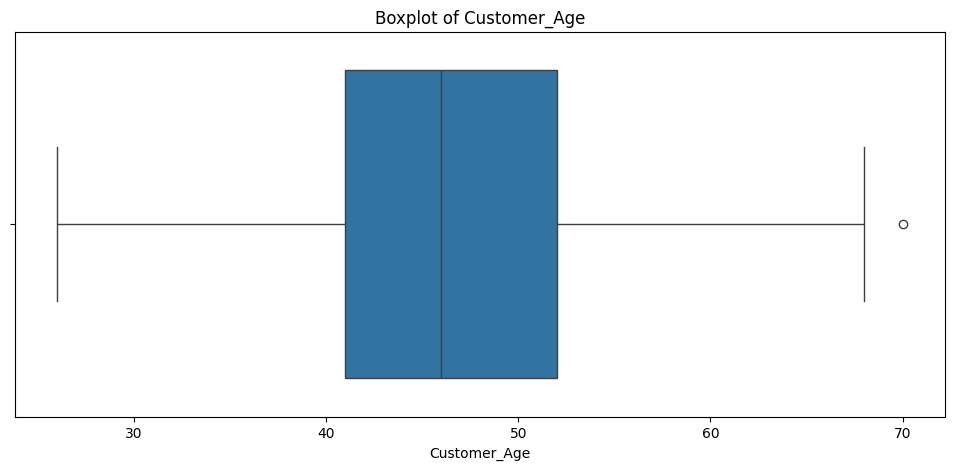

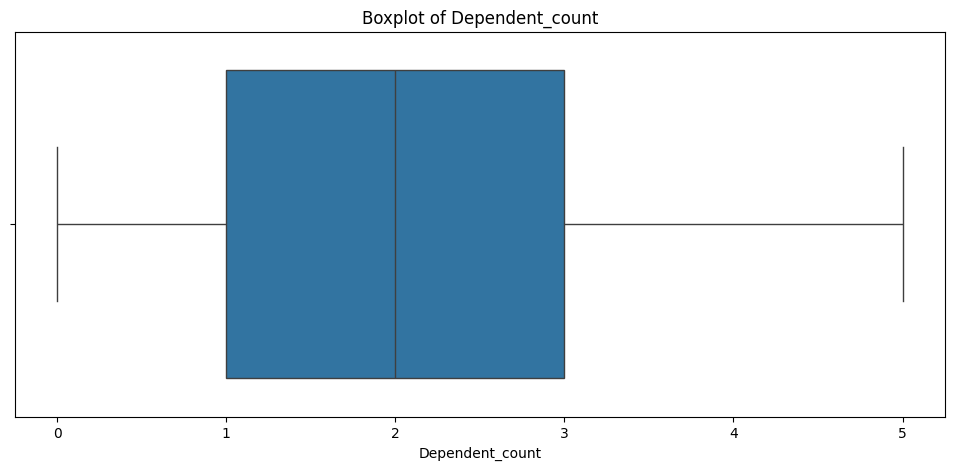

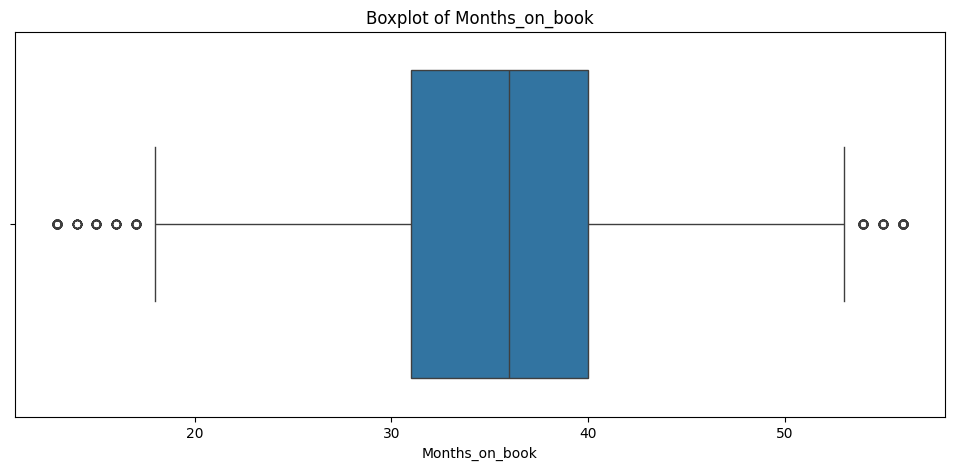

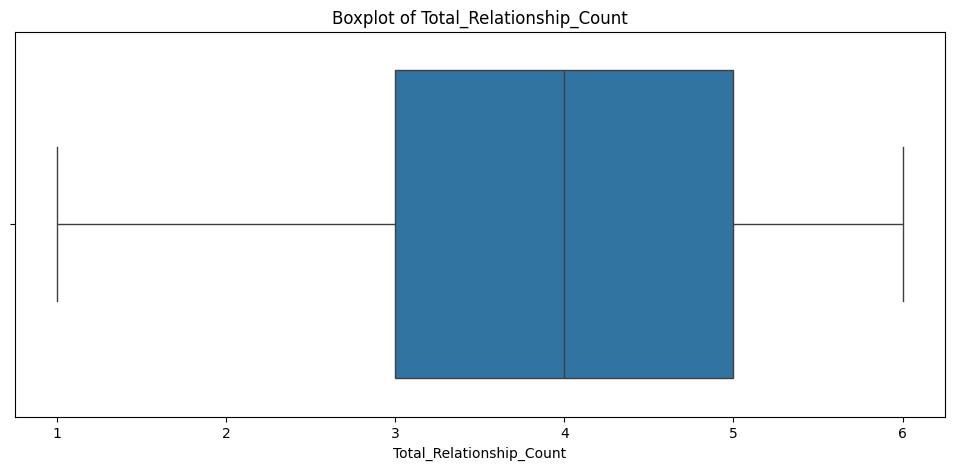

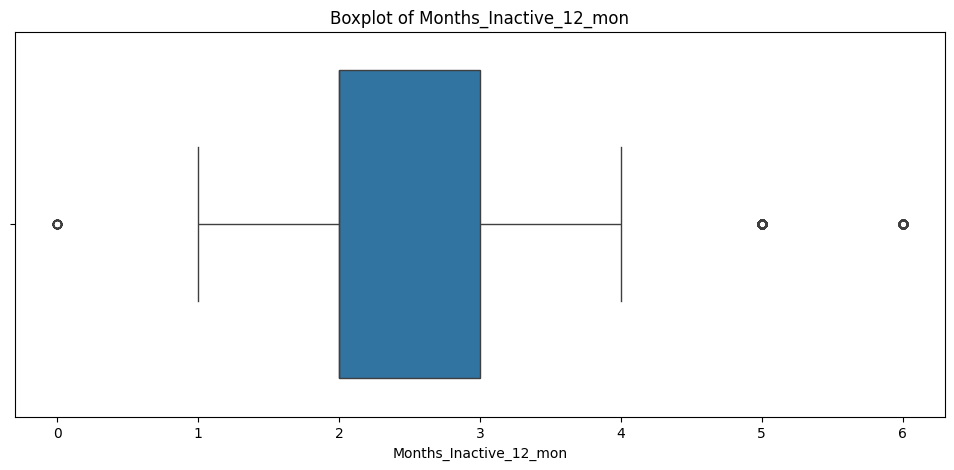

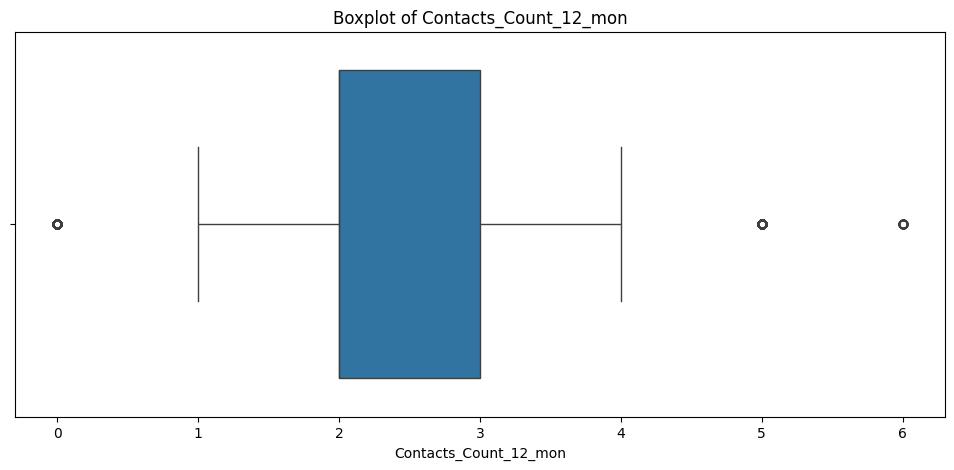

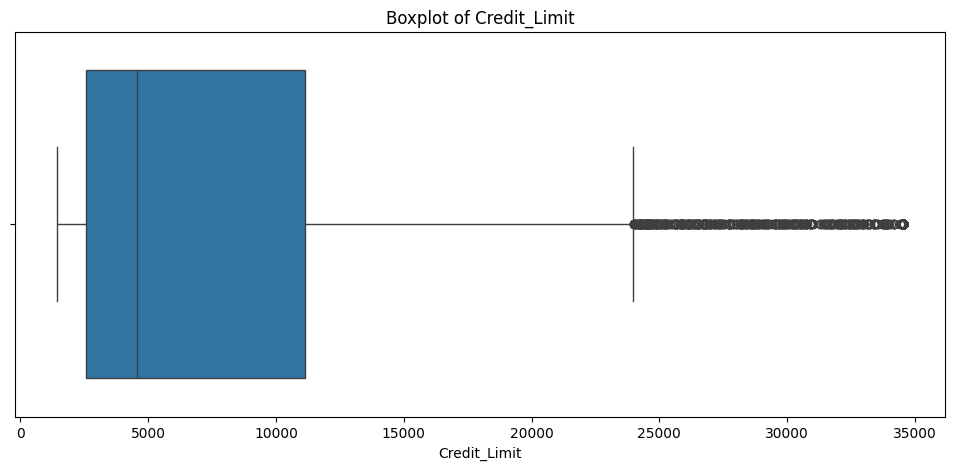

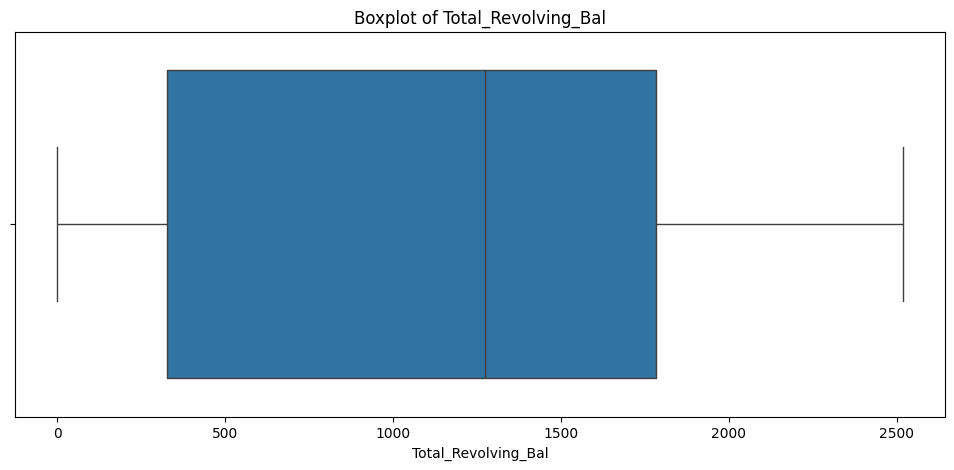

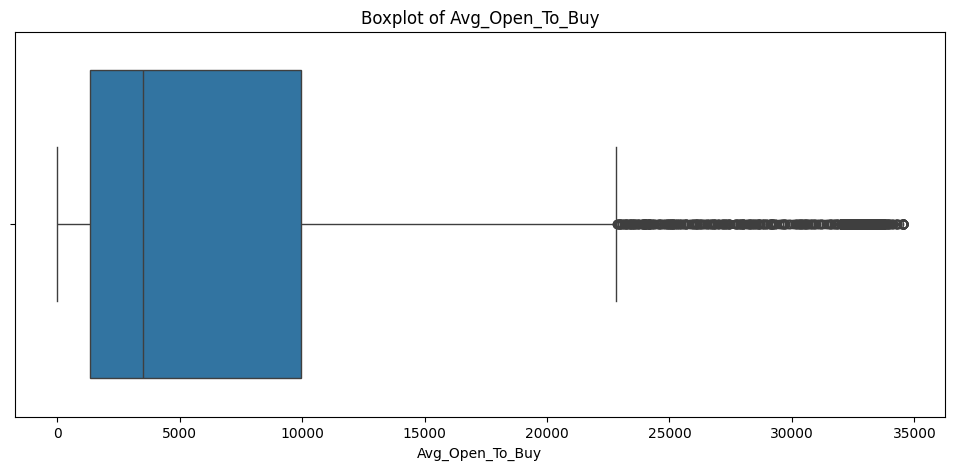

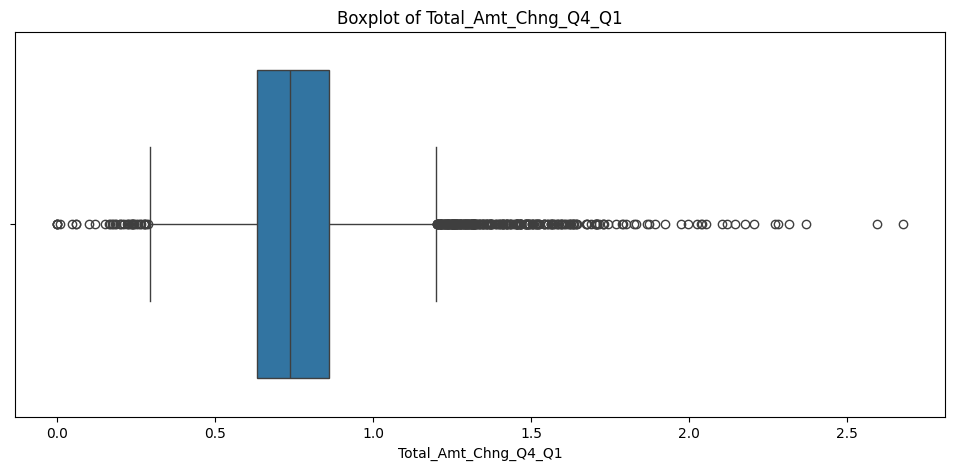

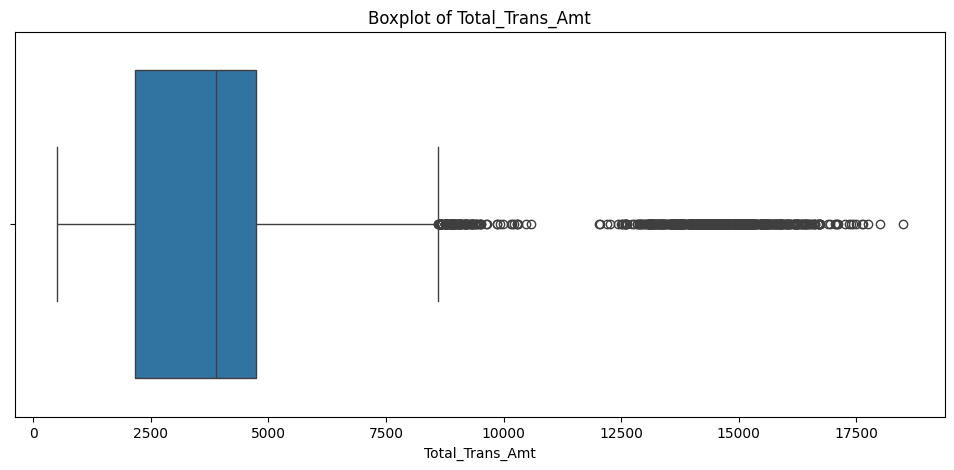

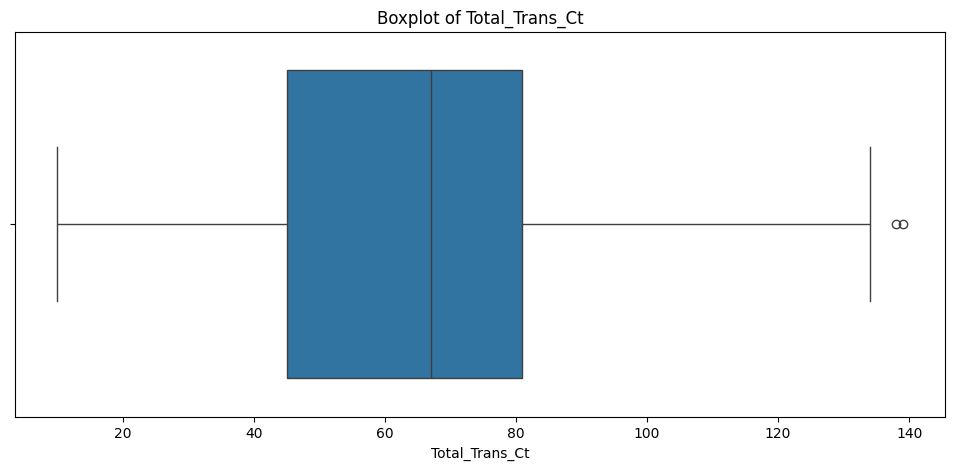

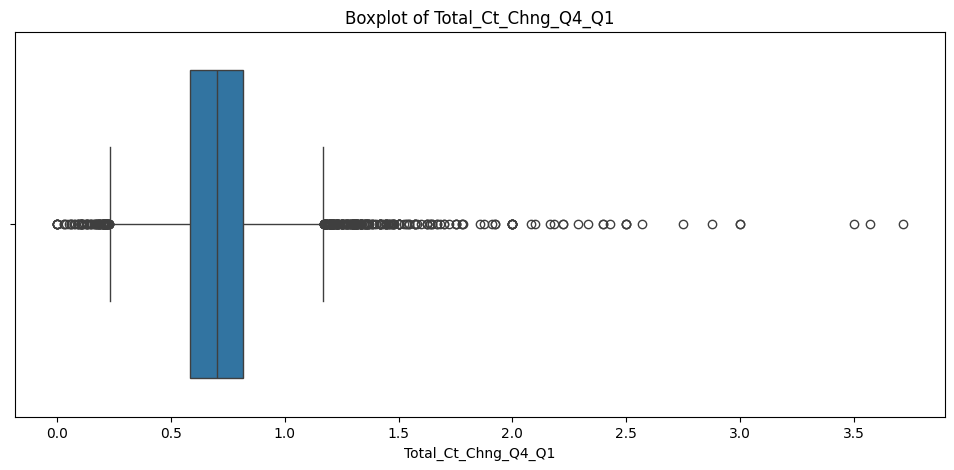

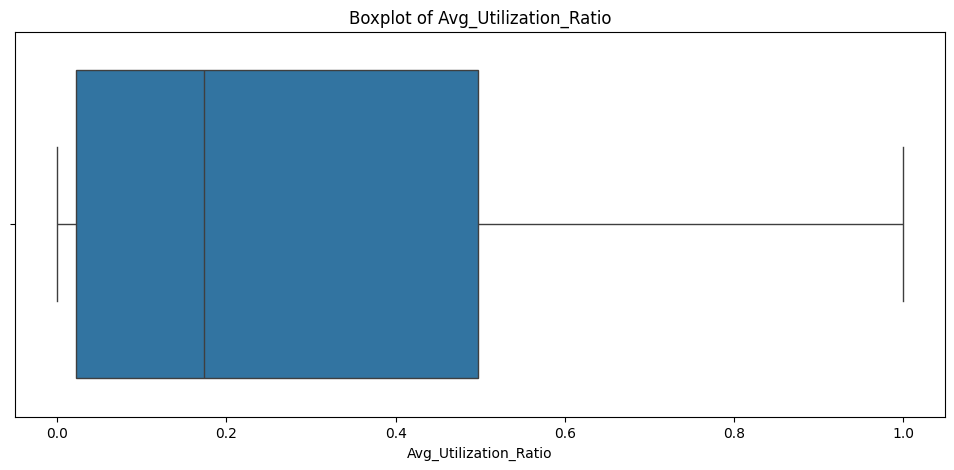

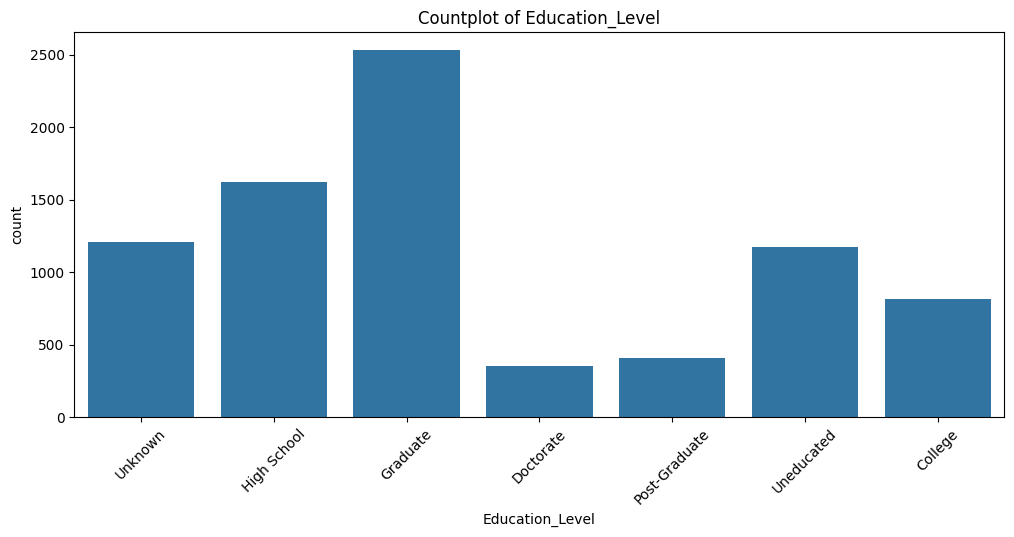

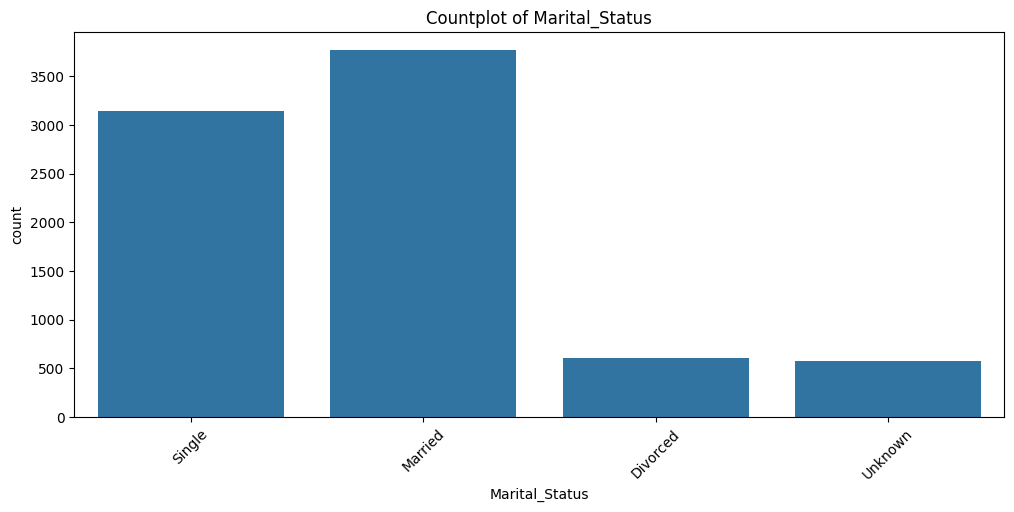

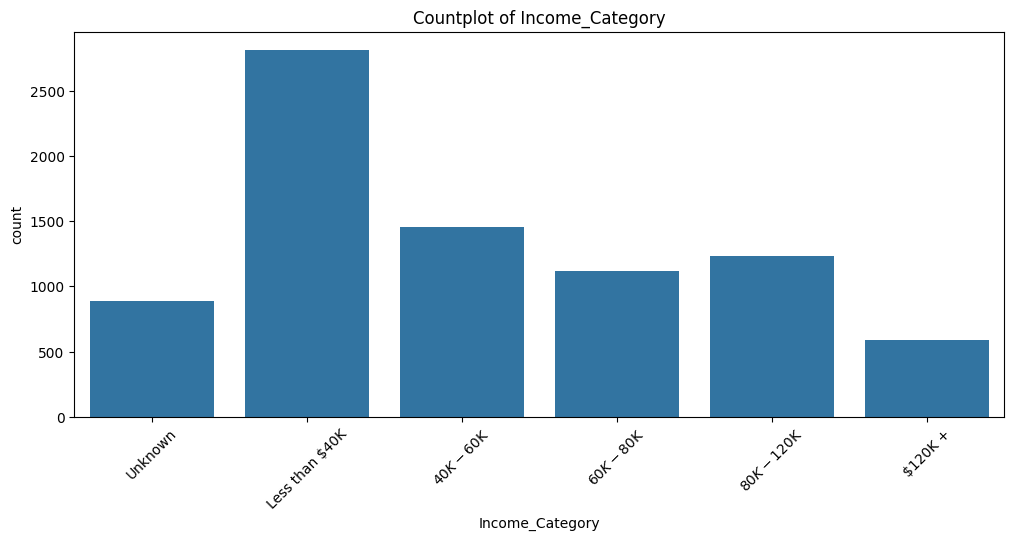

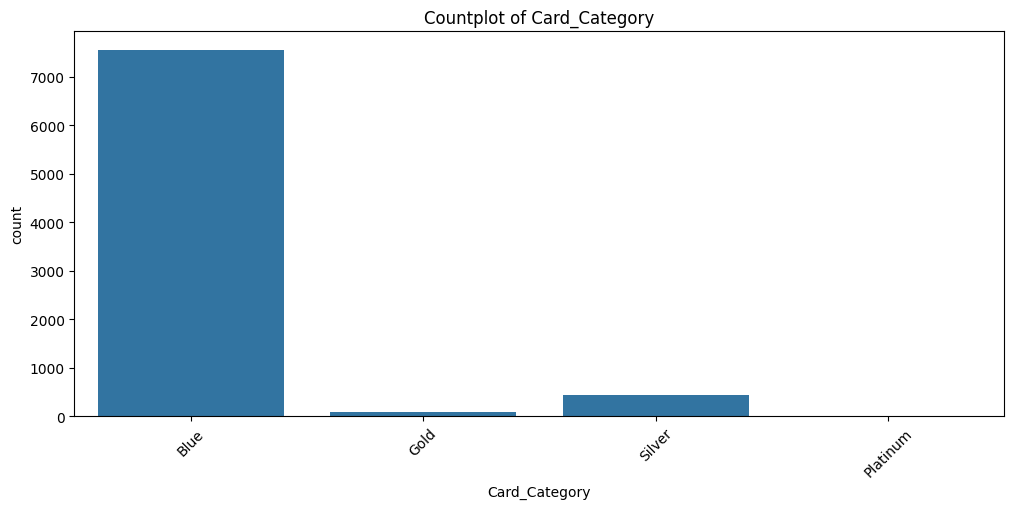

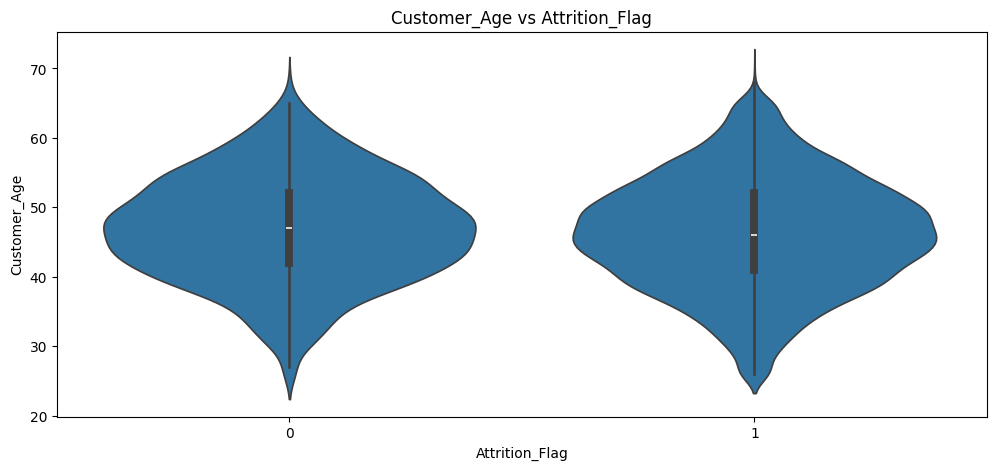

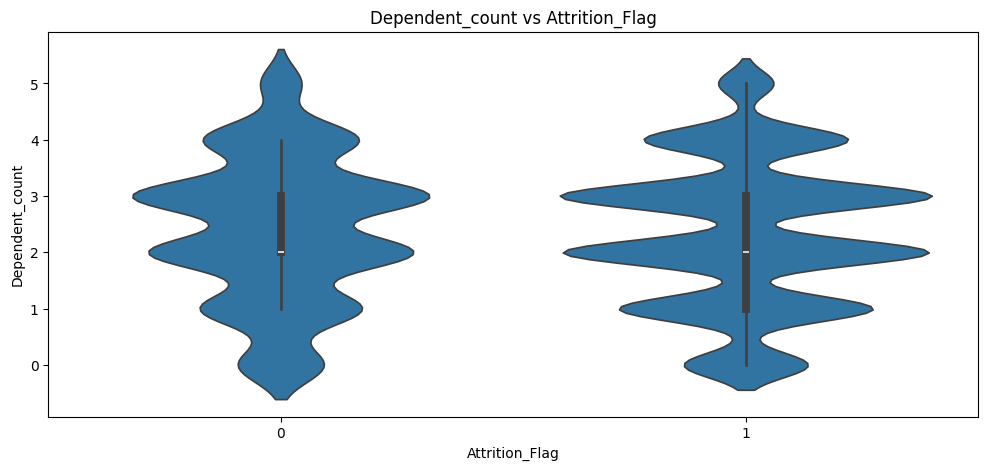

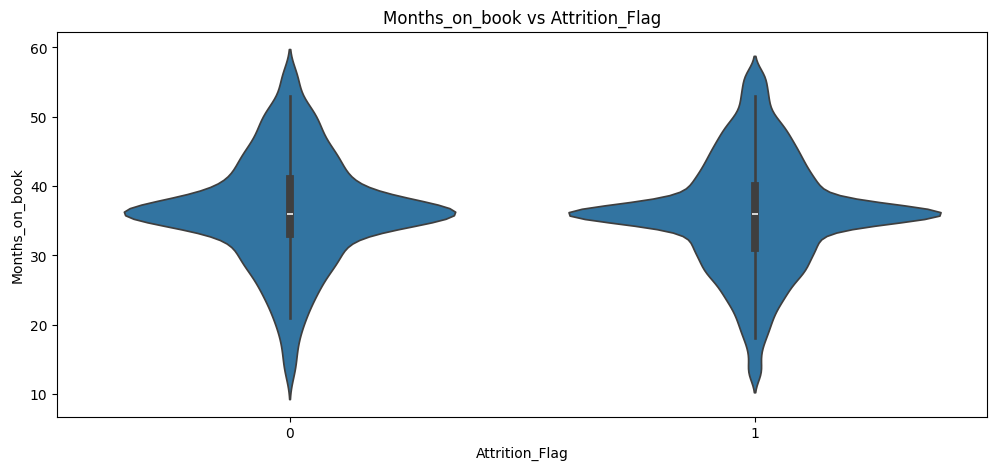

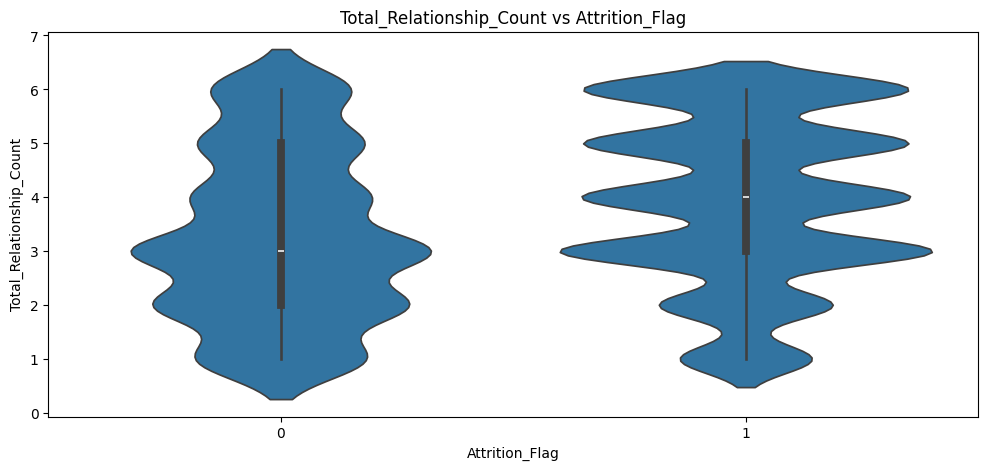

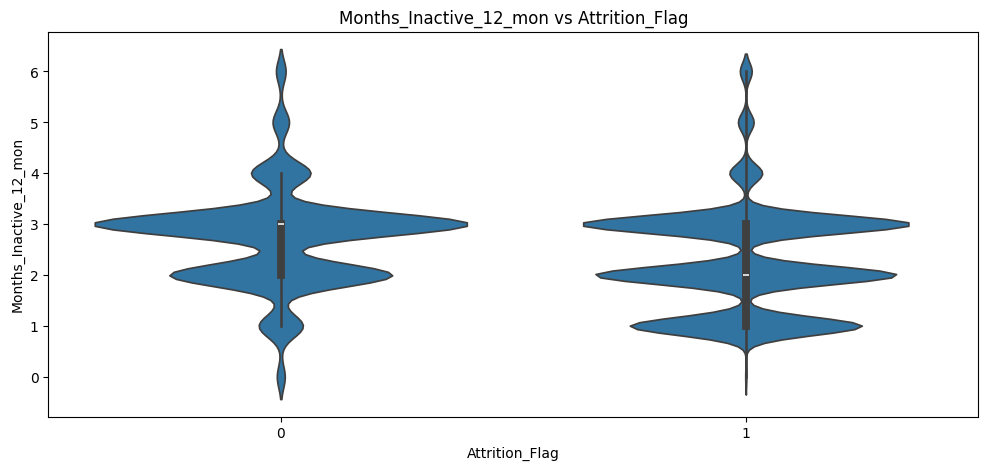

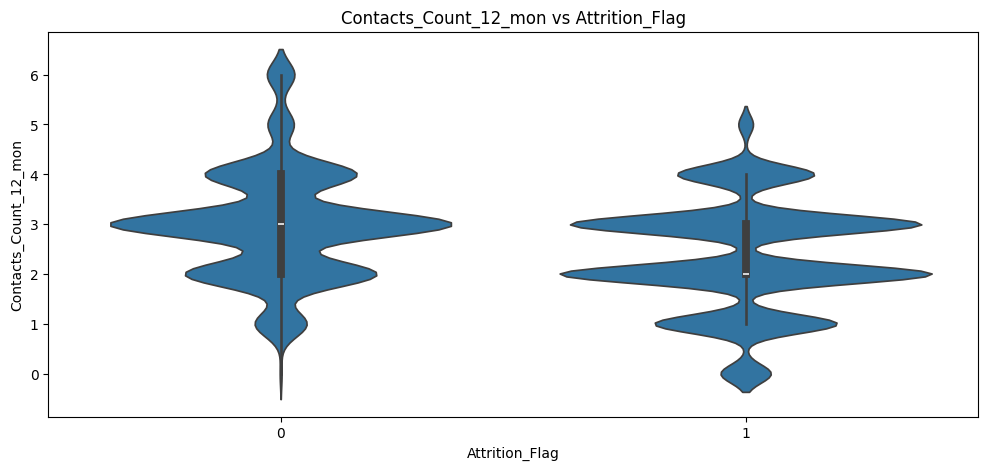

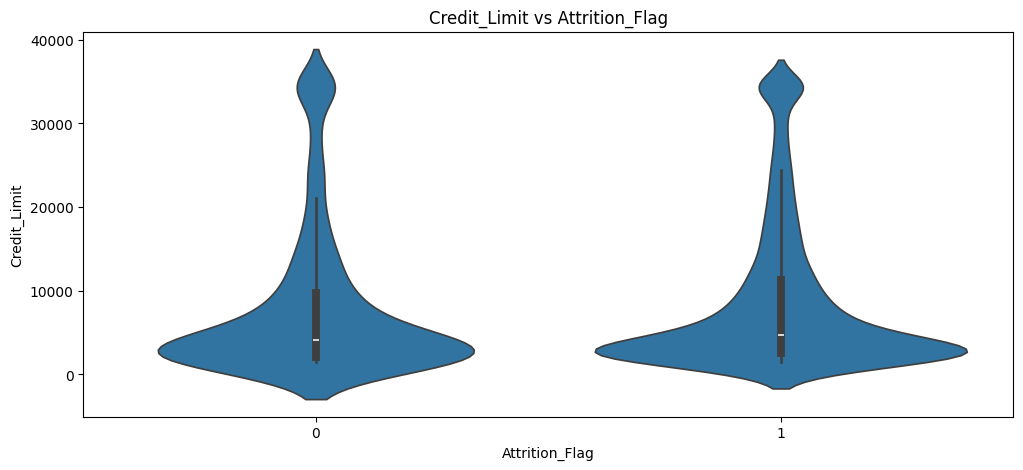

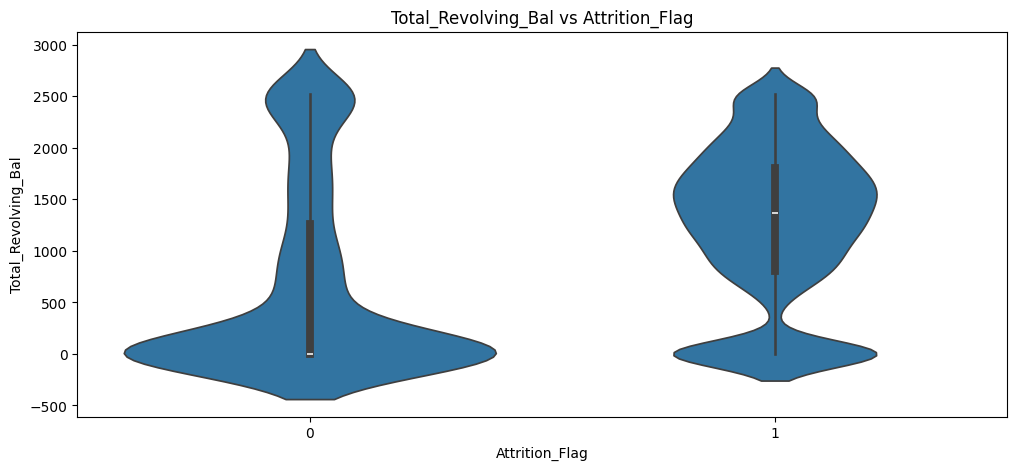

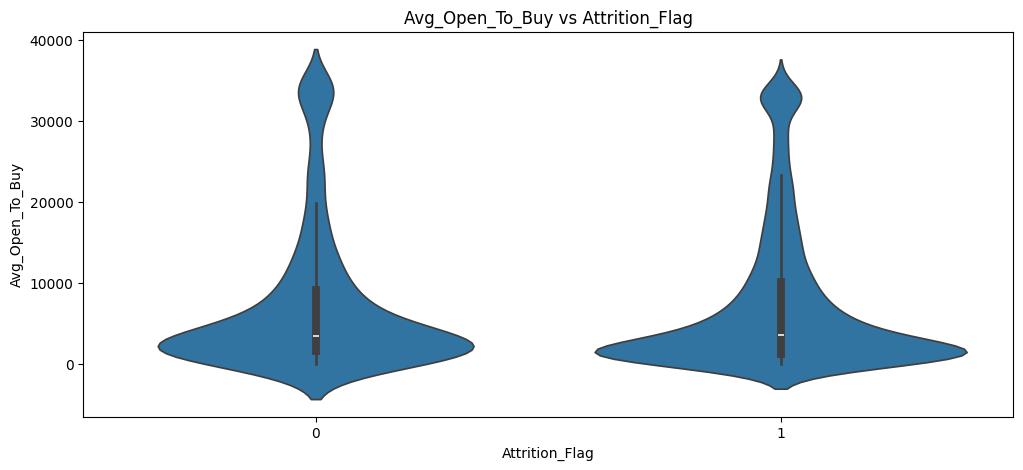

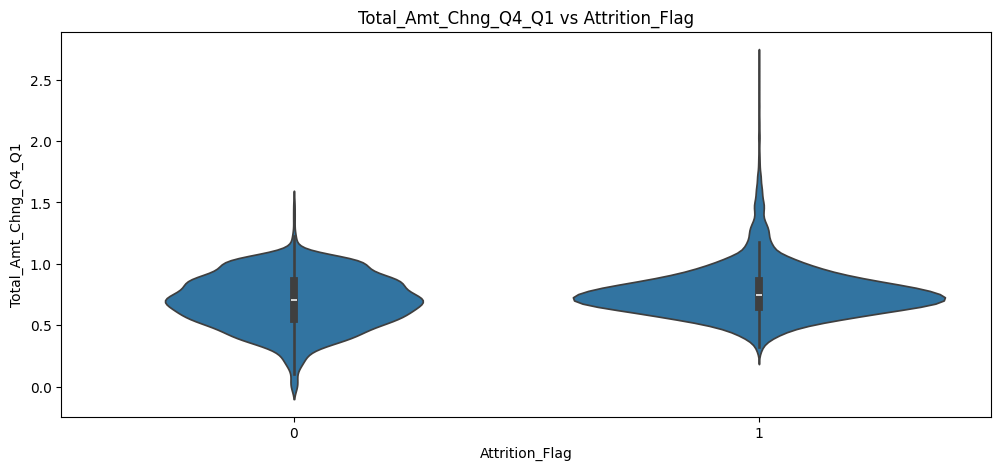

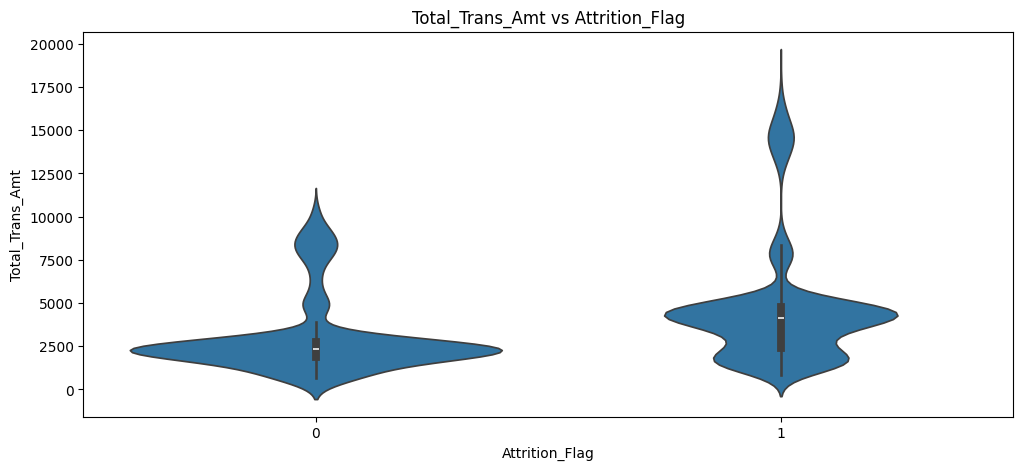

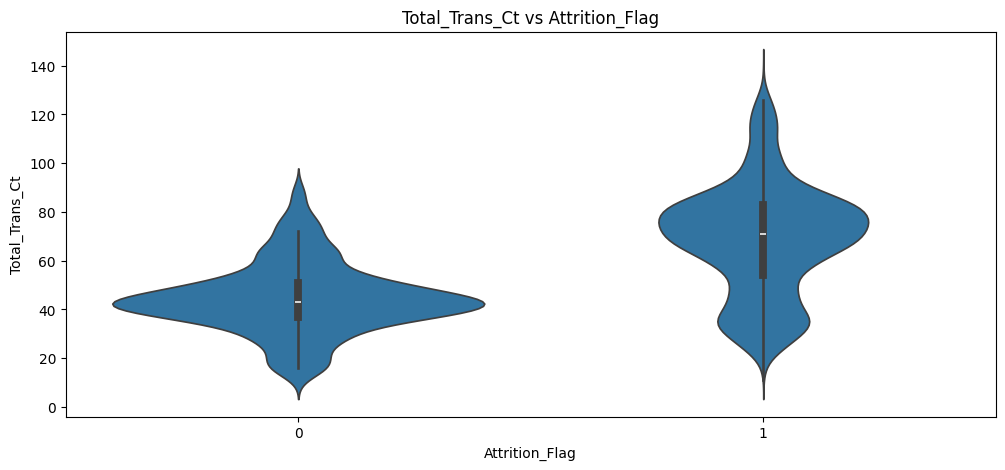

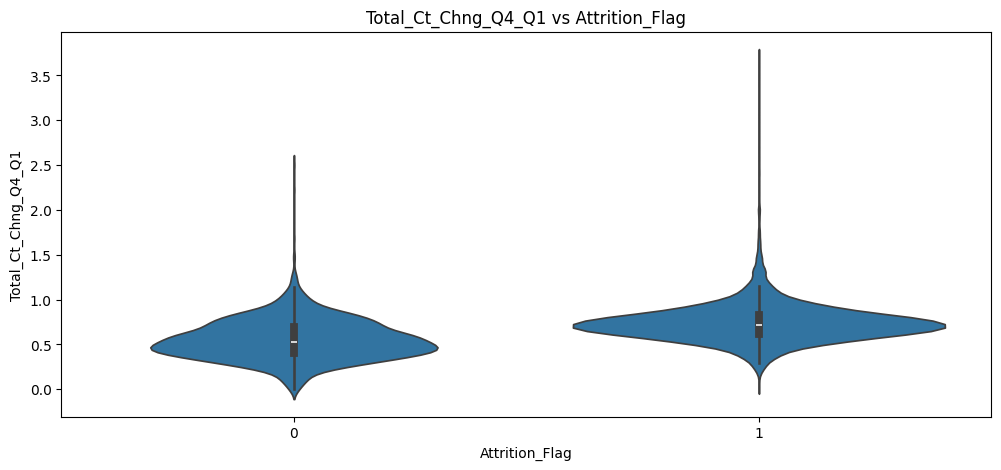

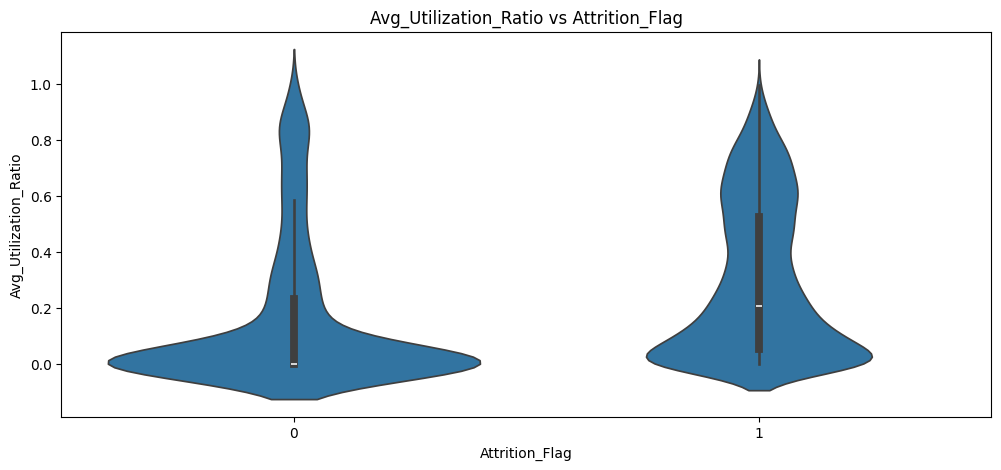

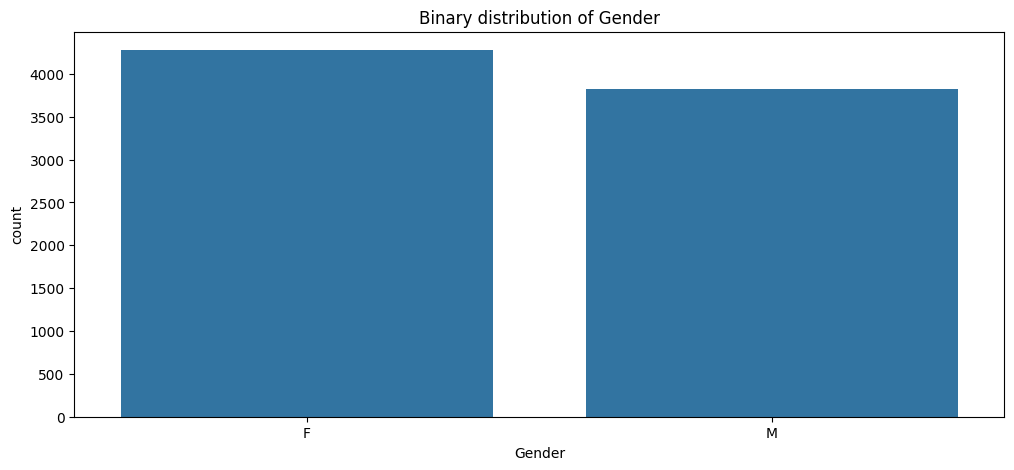


Gender value counts:
Gender
F    4279
M    3822
Name: count, dtype: int64


In [122]:
eda = EDA(df_train, num, cat, binary, target)

eda.plot_numerical()
eda.plot_categorical()
eda.plot_target_relationship()
eda.plot_binary()

Income_Category, Marital_Status, Education_Level: These contain an "Unknown" category.

Card_Category, Income_Category, Education_Level: These are ordinal categories. They can be converted to numeric values with statistical meaning.

Dilemma: Should I remove outliers to make the model more accurate? I have few of them.

### Relationship with Target Variable

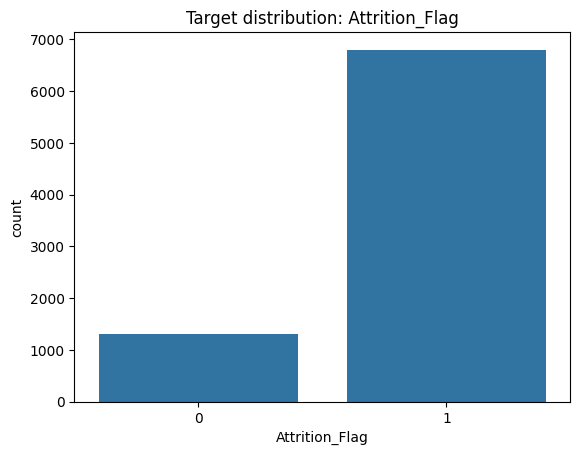

In [123]:
sns.countplot(data=df_train, x=target)
plt.title('Target distribution: '+ target)
plt.show()

The data needs to be rebalanced.

In this case, F1 is one of the best metrics, as it balances other evaluation metrics.

In [124]:
# Class to plot distributions by target class
class TargetEDA:
    def __init__(self, df, num, cat, binary, target):
        self.df = df
        self.num = num
        self.cat = cat
        self.binary = binary
        self.target = target

    def plot_numerical_vs_target(self):
        for col in self.num:
            plt.figure(figsize=(12, 5))
            sns.violinplot(x=self.target, y=col, data=self.df)
            plt.title(f'{col} vs {self.target}')
            plt.xlabel(self.target)
            plt.ylabel(col)
            plt.show()

    def plot_categorical_vs_target(self):
        for col in self.cat:
            plt.figure(figsize=(12, 5))
            sns.countplot(x=col, hue=self.target, data=self.df)
            plt.title(f'{col} distribution by {self.target}')
            plt.xticks(rotation=45)
            plt.show()

    def plot_binary_vs_target(self):
        for col in self.binary:
            plt.figure(figsize=(12, 5))
            sns.countplot(x=col, hue=self.target, data=self.df)
            plt.title(f'{col} vs {self.target}')
            plt.show()

    def run(self):
        self.plot_numerical_vs_target()
        self.plot_categorical_vs_target()
        self.plot_binary_vs_target()


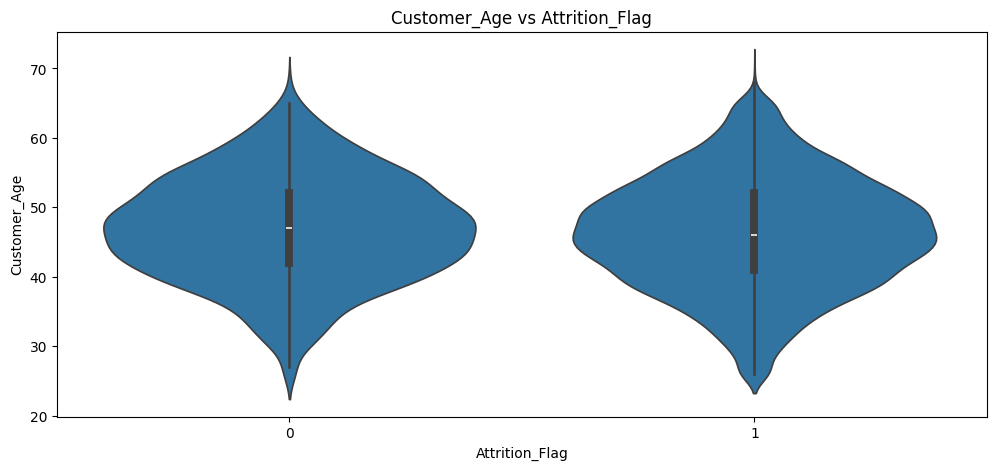

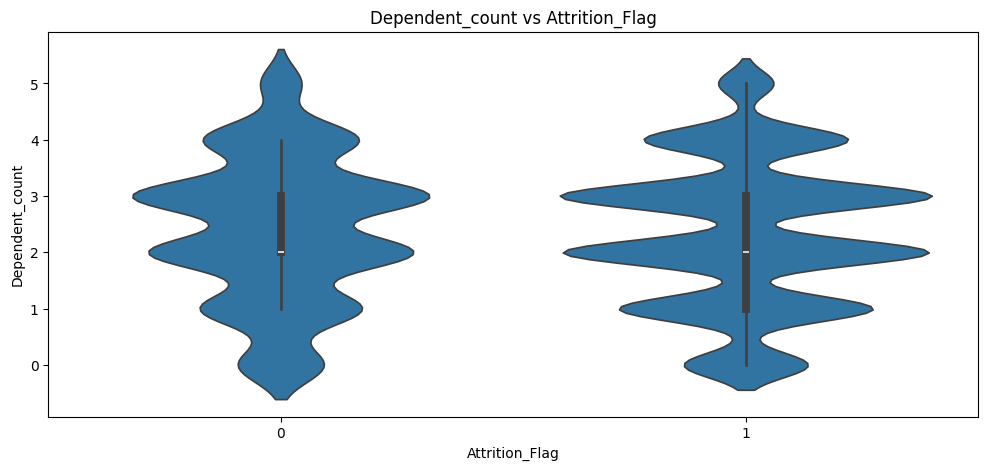

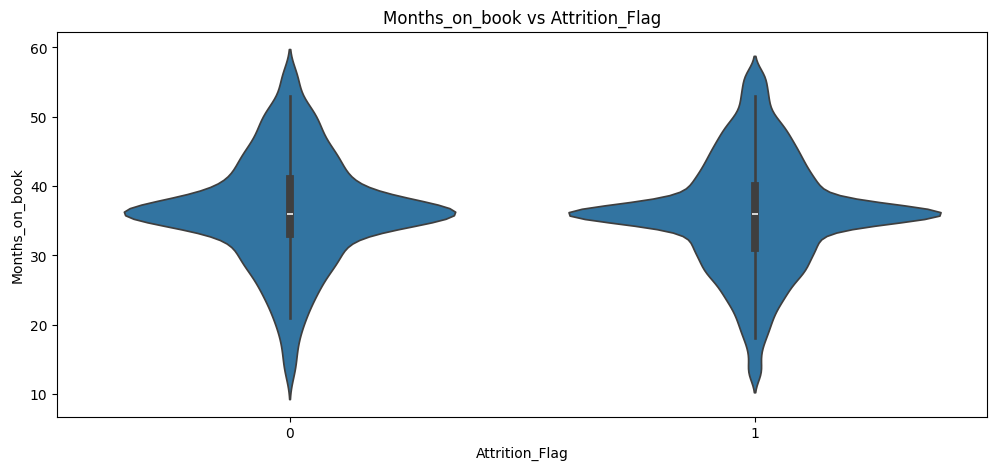

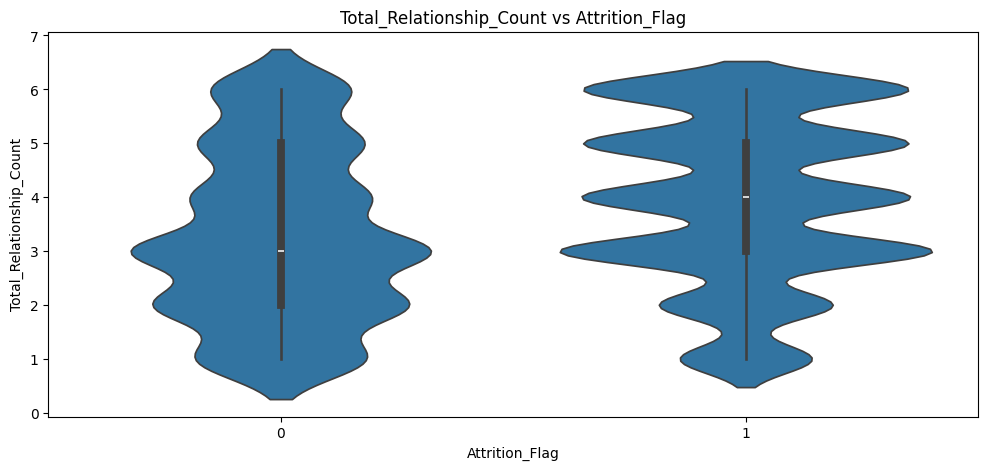

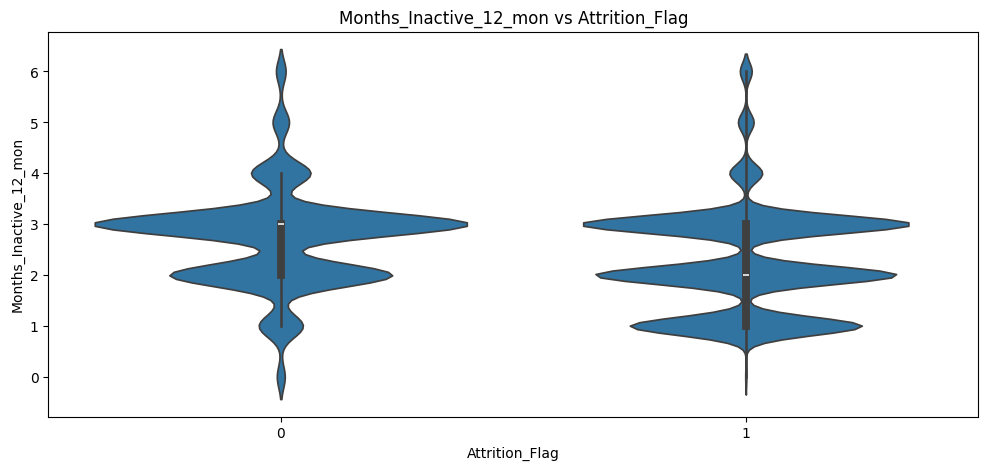

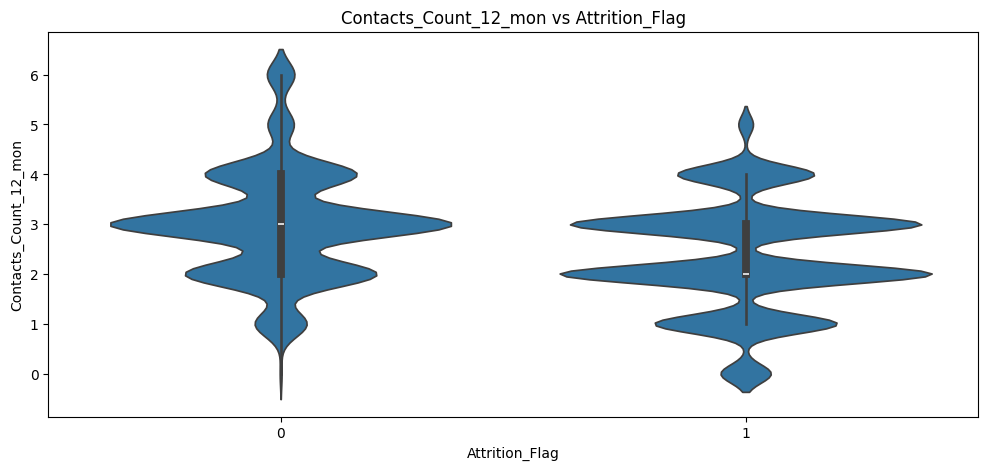

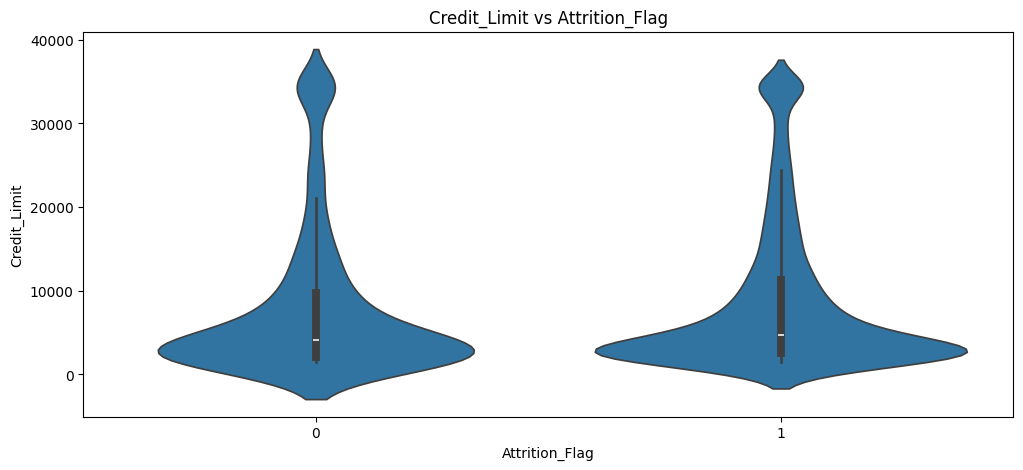

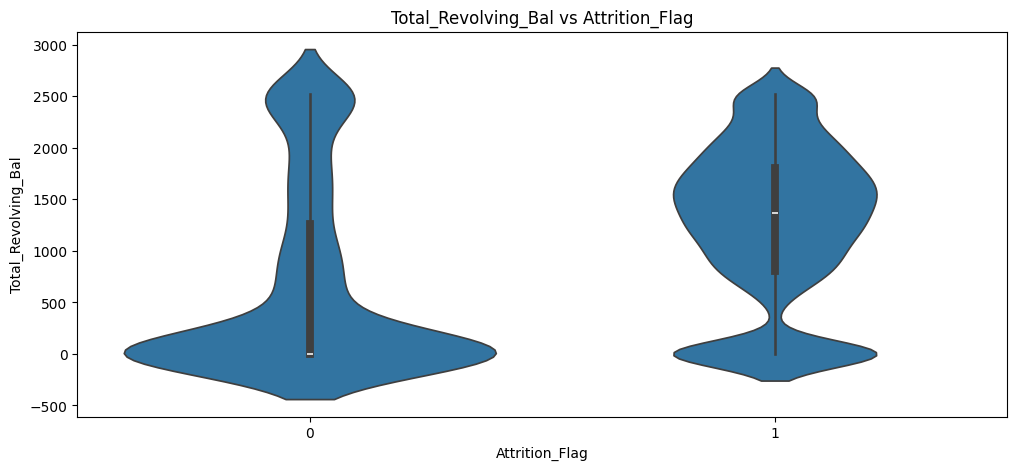

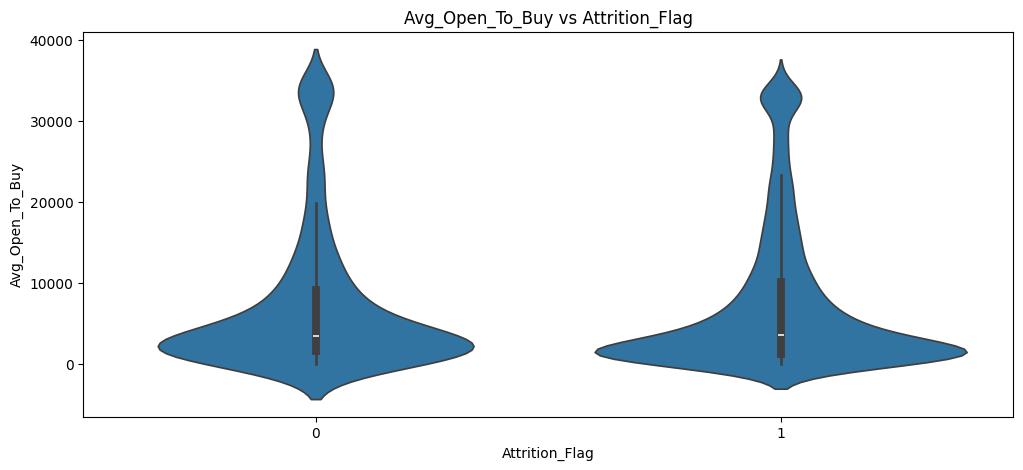

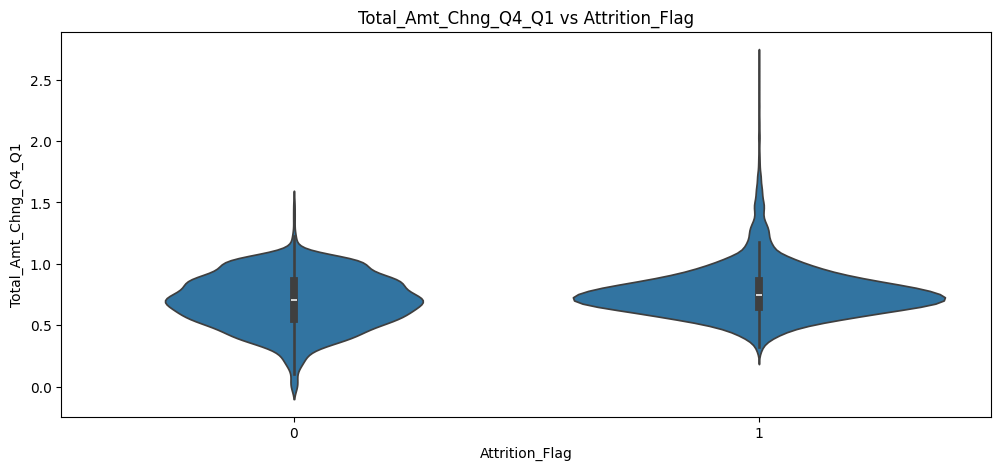

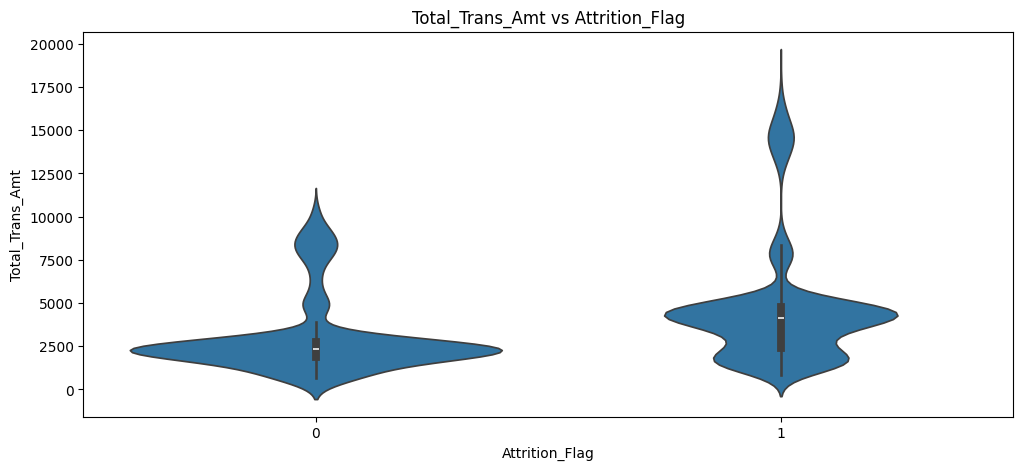

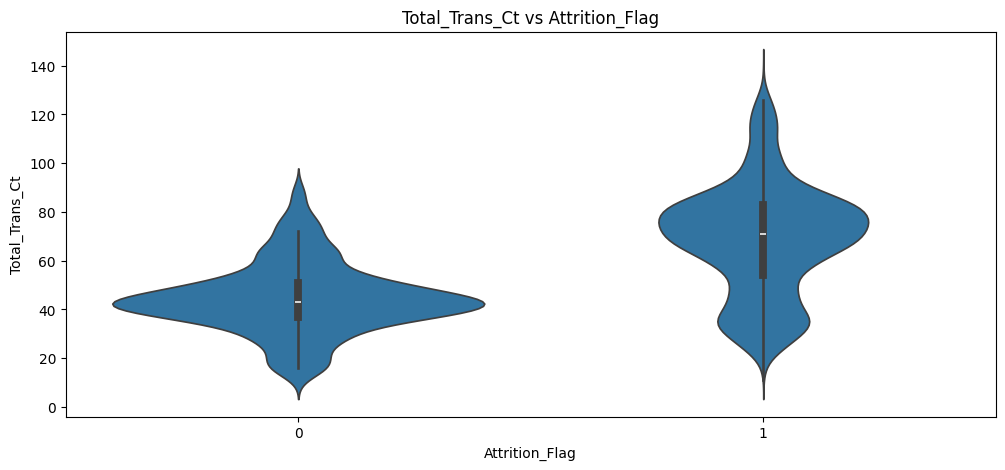

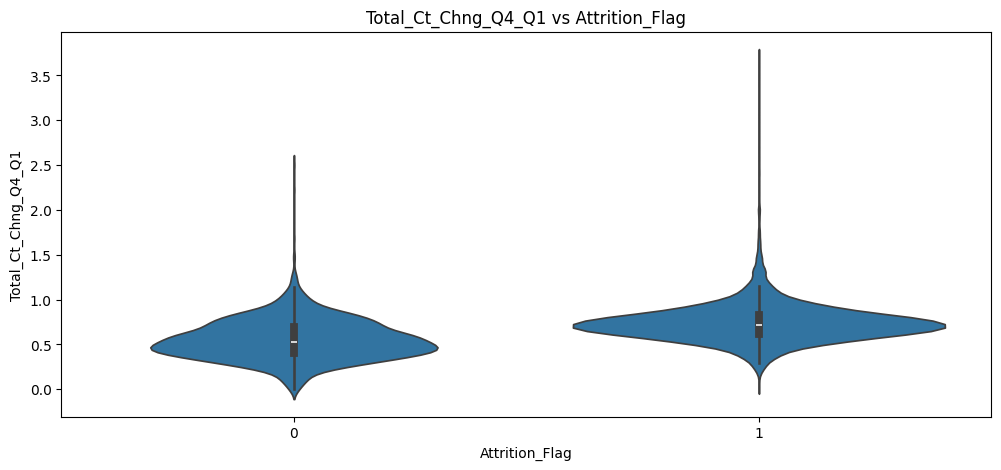

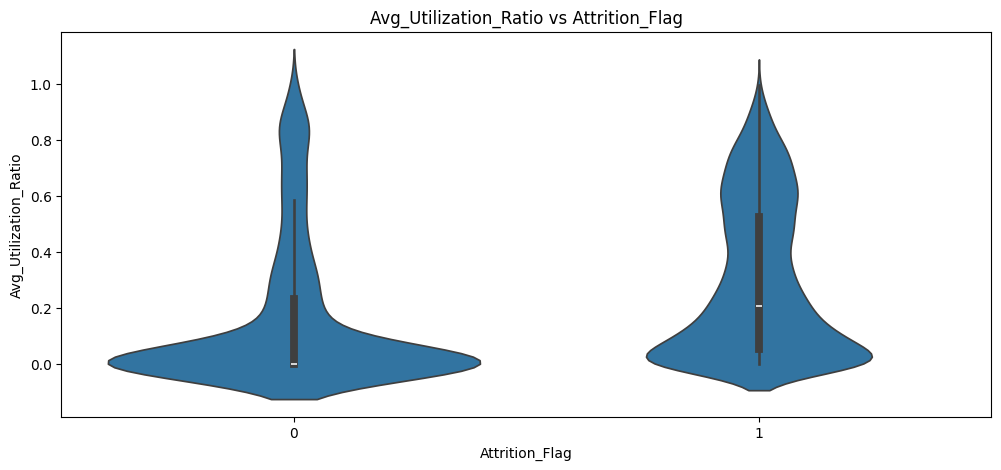

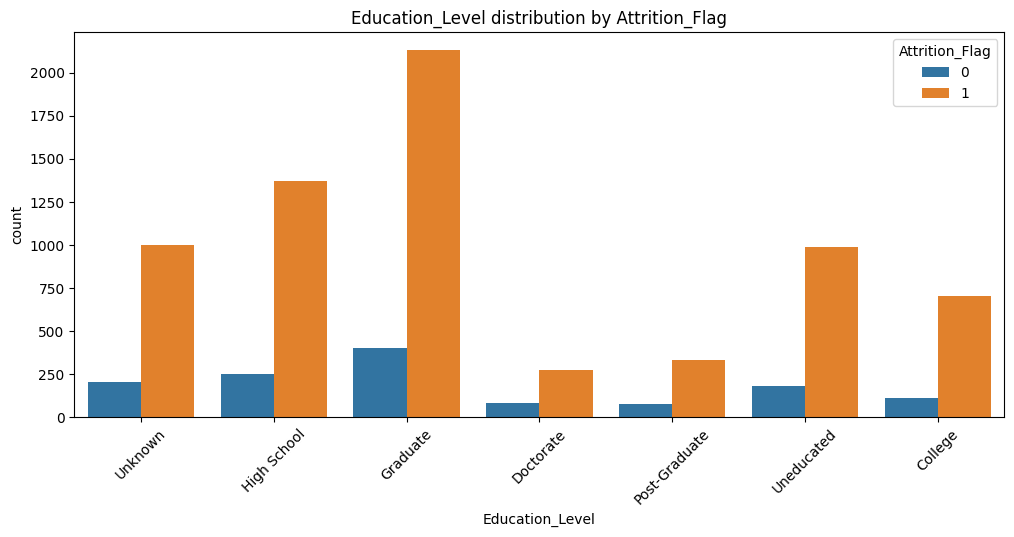

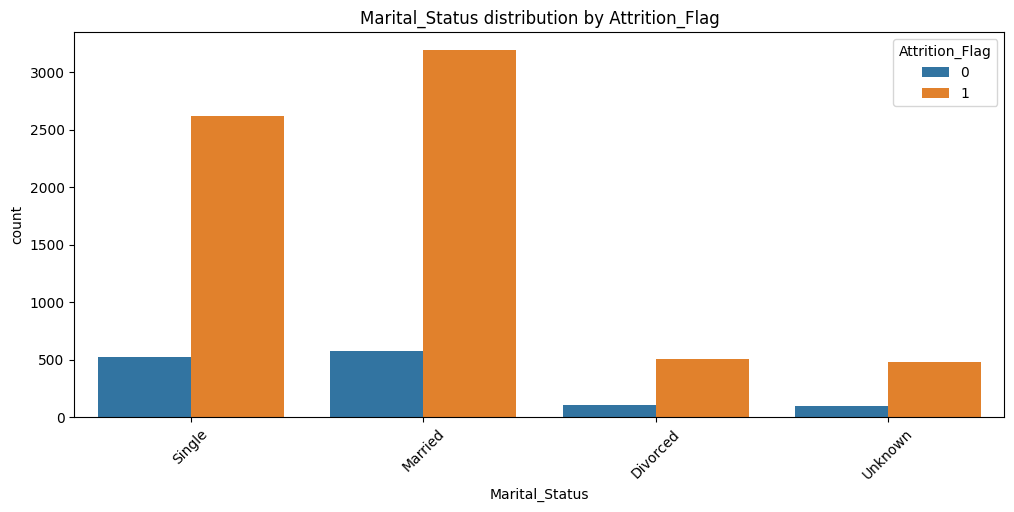

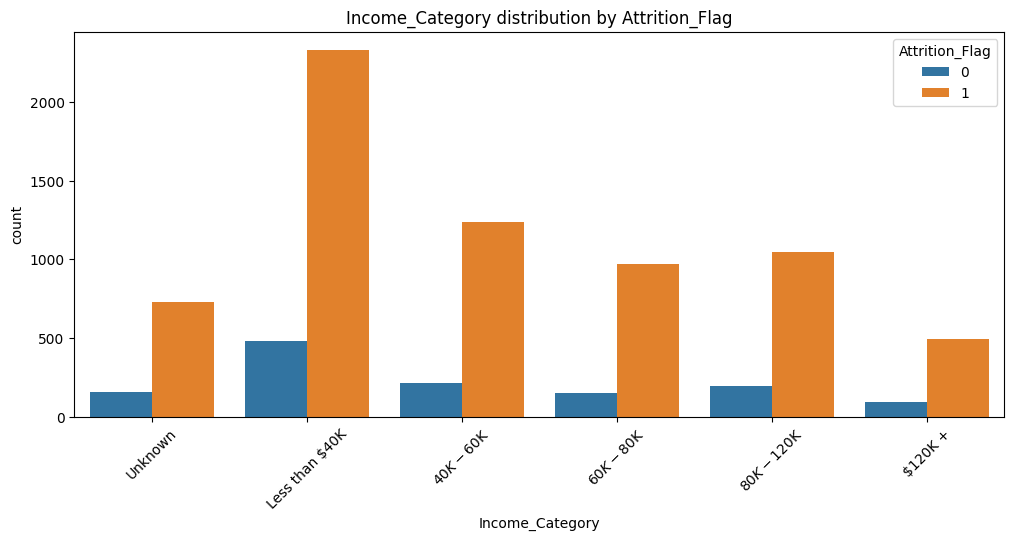

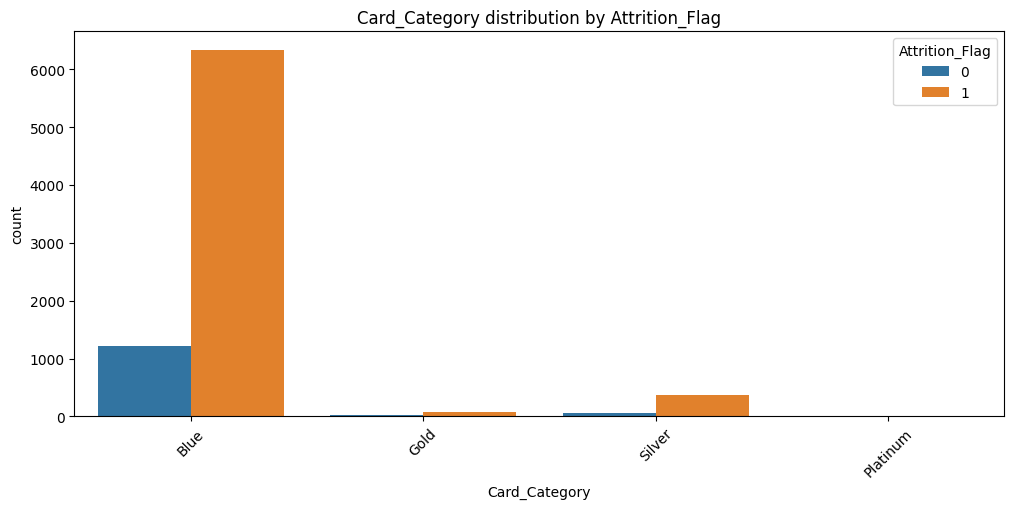

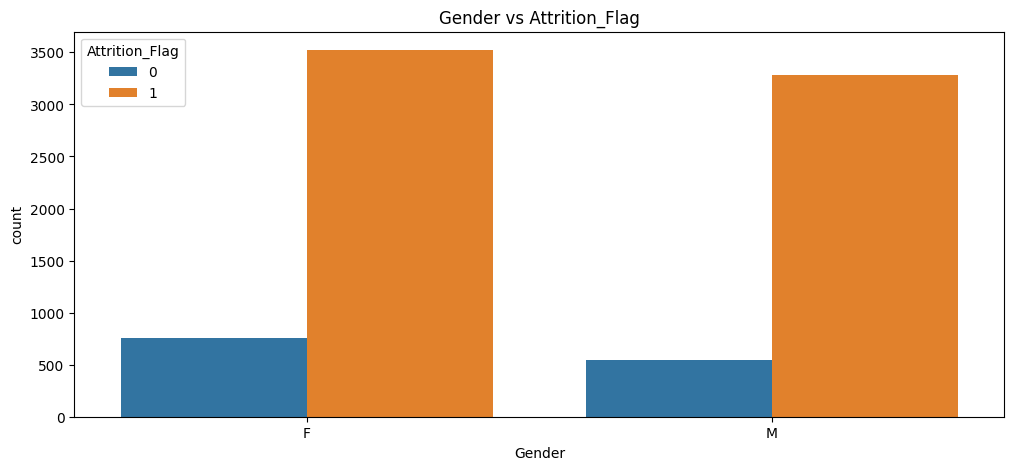

In [125]:
eda = TargetEDA(df_train, num, cat, binary, target)
eda.run()

### Insights


 - Income_Category: People who churn usually earn less than 40K
 - Total_Revolving_Bal: People who churn tend to have balances close to zero
 - Total_Trans_Amt: People who churn make fewer transactions
 - Avg_Utilization_Ratio: People who churn don’t use the service much

### Preprocessing Pipeline

Income_Category, Marital_Status, Education_Level have unknown values

Card_Category, Income_Category, Education_Level are ordinal and can be numerically encoded

In [126]:
# Check distribution of education levels
df_train['Education_Level'].value_counts()

Education_Level
Graduate         2528
High School      1619
Unknown          1205
Uneducated       1171
College           816
Post-Graduate     407
Doctorate         355
Name: count, dtype: int64

In [127]:
# Transformer to flag 'Unknown' values
class UnknownTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy()
        for col, unknown_col in self.columns.items():
            unknown = df[col] == 'Unknown'
            df[unknown_col] = unknown.astype(int)
        return df

In [128]:
class CategoricalToNumeric(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):

        df = X.copy()

        df['Education_Level'] = df['Education_Level'].replace({
            'Uneducated': 0,
            'College': 1,
            'High School': 2,
            'Graduate': 3,
            'Post-Graduate': 4,
            'Doctorate': 5,
            'Unknown': -1,
        }).astype(int)

        df['Income_Category'] = df['Income_Category'].replace({
            'Less than $40K': 0,
            '$40K - $60K': 1,
            '$60K - $80K': 2,
            '$80K - $120K': 3,
            '$120K +': 4,
            'Unknown': -1,
        }).astype(int)

        df['Card_Category'] = df['Card_Category'].replace({
            'Blue': 0,
            'Silver': 1,
            'Gold': 2,
            'Platinum': 3,
        }).astype(int)

        return df

In [129]:
# Drops the client ID and sets the index
class DataFrameProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, index_column):
        self.index_column = index_column

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_train = X.drop(['CLIENTNUM'], axis=1)
        X_train.set_index([self.index_column], inplace=True)
        return X_train

In [130]:
# Converts array to DataFrame
class ArrayToDataFrameTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column_names=None):
        self.column_names = column_names

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.column_names is None:
            self.column_names = ['col{}'.format(i) for i in range(X.shape[1])]
        return pd.DataFrame(X, columns=self.column_names)


In [131]:
# Label encoder for multiple columns
class MultiColumnLabelEncoder:
    def __init__(self, columns=None):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        output = X.copy()
        le = LabelEncoder()
        for col in self.columns:
            output[col] = le.fit_transform(output[col])
        return output

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [132]:
# Create transformation pipelines
pipe_train = Pipeline(steps=[
    ('UnknownTransformer', UnknownTransformer({'Education_Level': 'Education_Level_Unknown',
                                               'Income_Category': 'Income_Category_Unknown'})),
    ('CategoricalToNumeric', CategoricalToNumeric()),
    ('DataFrameProcessor', DataFrameProcessor('train_idx')),
    ('Encoder', MultiColumnLabelEncoder(columns=['Gender', 'Marital_Status'])),
])

In [133]:
pipe_test = Pipeline(steps=[
    ('UnknownTransformer', UnknownTransformer({'Education_Level': 'Education_Level_Unknown', 'Income_Category': 'Income_Category_Unknown'})),
    ('CategoricalToNumeric', CategoricalToNumeric()),
    ('DataFrameProcessor', DataFrameProcessor('test_idx')),
    ('Encoder', MultiColumnLabelEncoder(columns=['Gender', 'Marital_Status'])),
])

In [134]:
# Apply transformations
pipe_train = pipe_train.fit_transform(df_train)
pipe_train

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag,Education_Level_Unknown,Income_Category_Unknown
train_idx,,,,,,,,,,,,,,,,,,,,,
0,54,0,1,-1,2,-1,0,36,1,3,...,1728,1995.0,0.595,8554,99,0.678,0.464,1,1,1
1,58,0,4,2,1,-1,0,48,1,4,...,1803,3593.0,0.493,2107,39,0.393,0.334,0,0,1
2,45,0,4,-1,2,0,2,36,6,1,...,1648,14339.0,0.732,1436,36,1.250,0.103,1,1,0
3,34,0,2,3,2,0,0,36,4,3,...,2517,1108.0,1.158,2616,46,1.300,0.694,1,0,0
4,49,0,2,2,1,1,0,39,5,3,...,1926,794.0,0.602,3806,61,0.794,0.708,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8096,44,0,1,3,2,1,0,38,3,2,...,2517,1625.0,0.809,2104,44,0.833,0.608,0,0,0
8097,53,0,3,2,0,-1,0,36,4,3,...,0,7939.0,0.551,2269,42,0.312,0.000,0,0,1
8098,42,0,4,3,3,0,0,32,3,1,...,1547,767.0,0.804,4678,74,1.000,0.669,1,0,0


In [135]:
pipe_test = pipe_test.fit_transform(df_test)
pipe_test

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_Unknown,Income_Category_Unknown
test_idx,,,,,,,,,,,,,,,,,,,,,
0,48,0,3,0,2,0,0,39,4,3,...,2991.0,1508,1483.0,0.703,3734,64,0.882,0.504,0,0
1,59,1,1,0,2,0,0,53,5,5,...,2192.0,1569,623.0,0.706,4010,79,0.717,0.716,0,0
2,37,0,2,3,0,0,0,36,4,3,...,1734.0,987,747.0,0.879,4727,67,0.914,0.569,0,0
3,47,1,3,5,0,1,0,36,4,2,...,4786.0,1516,3270.0,0.940,4973,74,0.850,0.317,0,0
4,42,1,3,-1,2,3,0,33,3,3,...,3714.0,2170,1544.0,0.524,1454,35,0.522,0.584,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,34,1,2,3,2,3,0,29,3,1,...,13395.0,1678,11717.0,1.006,2650,69,0.865,0.125,0,0
2022,35,0,1,1,2,0,0,25,2,2,...,2231.0,1791,440.0,0.820,2576,42,0.750,0.803,0,0
2023,44,0,1,0,0,0,0,37,1,2,...,5594.0,1235,4359.0,0.549,5220,75,0.829,0.221,0,0


### Feature and Target Separation

In [136]:
X_train=pipe_train.drop(target, axis=1)
y_train=pipe_train[target]
X_test=pipe_test
# y_test=?
# y_pred

In [137]:
X_train.sample(5)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_Unknown,Income_Category_Unknown
train_idx,,,,,,,,,,,,,,,,,,,,,
1808,41,1,2,1,1,3,0,31,1,1,...,3306.0,706,2600.0,0.814,4772,76,0.900,0.214,0,0
6661,52,0,3,2,2,0,0,45,3,3,...,2728.0,1365,1363.0,0.648,4293,83,0.976,0.500,0,0
7215,39,0,2,3,2,0,0,27,1,3,...,1438.3,811,627.3,0.571,2336,46,0.278,0.564,0,0
3527,37,0,1,3,2,0,0,36,6,2,...,6827.0,0,6827.0,0.754,2621,49,0.815,0.000,0,0
5677,36,0,0,-1,1,0,0,24,4,3,...,2570.0,2230,340.0,0.686,1755,42,0.448,0.868,1,0


In [138]:
y_train.sample(5)

train_idx
6072    1
5891    1
7751    1
2310    1
7811    1
Name: Attrition_Flag, dtype: int64

In [139]:
X_test.sample(5)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_Unknown,Income_Category_Unknown
test_idx,,,,,,,,,,,,,,,,,,,,,
652,47,1,5,3,2,2,0,36,6,3,...,2721.0,1264,1457.0,0.796,4557,71,0.972,0.465,0,0
961,43,0,4,3,3,1,0,31,2,3,...,4091.0,1108,2983.0,0.774,5244,87,0.706,0.271,0,0
119,46,0,3,5,2,0,0,36,5,1,...,2201.0,651,1550.0,0.825,3165,65,0.585,0.296,0,0
177,50,0,4,-1,1,0,0,36,2,4,...,2407.0,1102,1305.0,0.736,4543,71,0.775,0.458,1,0
1756,39,1,2,2,3,2,0,32,3,2,...,1715.0,0,1715.0,0.896,5910,91,0.517,0.000,0,0


Next Steps:
Normalize the data

Rebalance the data

MODELS

In [140]:
# Define a function to compute F1 score on training data
def f1(model, X, y):
    model.fit(X, y)  # Train the model on the provided data
    return f1_score(y, model.predict(X))  # Return the F1 score based on predictions

# Define a function to compute F1 score using cross-validation
def f1_cross_validation(model, X, y):
    cross_val = cross_val_score(model, X, y, cv=4, scoring='f1')  # Perform 4-fold CV using F1 as metric
    return cross_val.mean()  # Return the average F1 score across folds

# Initialize empty lists to store model labels and their F1 scores
label_, f1_train_, f1_valida_ = [], [], []

In [141]:
# Function to evaluate a classification model using F1 score on both train and cross-validation
def evaluate_classification(label, model, X, y):
    f1_train = f1(model, X, y)  # Compute F1 score on training data
    f1_valida = f1_cross_validation(model, X, y)  # Compute F1 score using cross-validation

    label_.append(label)            # Store model label
    f1_train_.append(f1_train)      # Store training F1 score
    f1_valida_.append(f1_valida)    # Store cross-validation F1 score

    # Return a DataFrame with all results, sorted by cross-validation F1 score (descending)
    return pd.DataFrame({
        'Model': label_,
        'F1 Score Train': f1_train_,
        'F1 Score Cross-Valida': f1_valida_
    }).sort_values('F1 Score Cross-Valida', ascending=False)


In [142]:
# Check the distribution of the target variable (class balance)
df_train.Attrition_Flag.value_counts()

Attrition_Flag
1    6801
0    1300
Name: count, dtype: int64

In [143]:
# Evaluate Logistic Regression
evaluate_classification(
    label='LogisticRegression',  # Model name
    model=LogisticRegression(),  # Model instance
    X=X_train, y=y_train         # Features and target
)

# Evaluate Support Vector Classifier (default)
evaluate_classification(
    label='SVC',
    model=SVC(),
    X=X_train, y=y_train
)

# Evaluate Support Vector Classifier with class weights balanced
evaluate_classification(
    label='SVC_Rebalanced',
    model=SVC(class_weight='balanced'),
    X=X_train, y=y_train
)

# Evaluate Gradient Boosting Classifier
evaluate_classification(
    label='GradientBoosting',
    model=GradientBoostingClassifier(),
    X=X_train, y=y_train
)

# Evaluate XGBoost Classifier
evaluate_classification(
    label='XGBoost',
    model=XGBClassifier(),
    X=X_train, y=y_train
)

# Evaluate Random Forest Classifier
evaluate_classification(
    label='RandomForestClassifier',
    model=RandomForestClassifier(),
    X=X_train, y=y_train
)

c:\Users\Machu\anaconda3\envs\churn\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Machu\anaconda3\envs\churn\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

,Model,F1 Score Train,F1 Score Cross-Valida
4,XGBoost,1.000000,0.983016
3,GradientBoosting,0.986197,0.980841
5,RandomForestClassifier,1.000000,0.976176
0,LogisticRegression,0.928303,0.930742
1,SVC,0.912763,0.912763
2,SVC_Rebalanced,0.818265,0.815814


I have tested different models using various algorithms to evaluate the performance of each one.

After doing some research, I found that for imbalanced datasets, algorithms like SVC, GradientBoosting, or RandomForest usually include regularization and are well-suited for these types of problems.

In this case, my final choice is between three algorithms (SVC, XGBoost, and GradientBoosting), based on the best performance, explainability, and suitability for imbalanced data.

The selected algorithm is GradientBoosting, because it is not as complex to explain as XGBoost and delivers very similar performance. Additionally, XGBoost is known for overfitting on new data. On the other hand, while SVC is known to perform well on imbalanced data, its lower performance led me to discard it from consideration.

### Prediction and Explainability

In [144]:
# Import the GradientBoostingClassifier model
GB = GradientBoostingClassifier()

# Train the model using the training data
Model_GradientBoostingClassifier = GB.fit(X_train, y_train)

In [145]:
# y_train_pred=
# Make predictions on the test set
y_test_pred = Model_GradientBoostingClassifier.predict(X_test)

# Display the count of predicted classes on the test set
pd.Series(y_test_pred).value_counts()

1    1733
0     293
Name: count, dtype: int64

In [146]:
# Predict class probabilities for the training set
y_train_pred_proba = Model_GradientBoostingClassifier.predict_proba(X_train)[:, 1]

# Predict class probabilities for the test set
y_test_pred_proba = Model_GradientBoostingClassifier.predict_proba(X_test)[:, 1]

# Print predicted probabilities for the training set
print(y_train_pred_proba)

# Print predicted probabilities for the test set
print(y_test_pred_proba)

[0.9854696  0.02363847 0.99399531 ... 0.99653776 0.99047229 0.99581721]
[0.99036956 0.99384861 0.99140461 ... 0.99414643 0.74553172 0.98531681]


In [147]:
# Define a function to display feature importance
def feature_importance(model, X_train):

    # Get feature importance values from the model
    f_importances = model.feature_importances_

    # Create a DataFrame with feature names and their importance scores
    top_features = pd.DataFrame({'feature': X_train.columns, 'importance': f_importances})

    # Sort the features by importance in descending order and reset index
    top_features = top_features.sort_values('importance', ascending=False).reset_index(drop=True)

    # Select the top 10 most important features
    top_features = top_features.head(10)

    # Set the size of the plot
    plt.figure(figsize=[15, 15])

    # Create a barplot of the top features
    sns.barplot(data=top_features, y='feature', x='importance', color='skyblue')

    # Add a title to the plot
    plt.title('Feature Importance')

    # Show the plot
    plt.show()

    # Return the top features
    return top_features

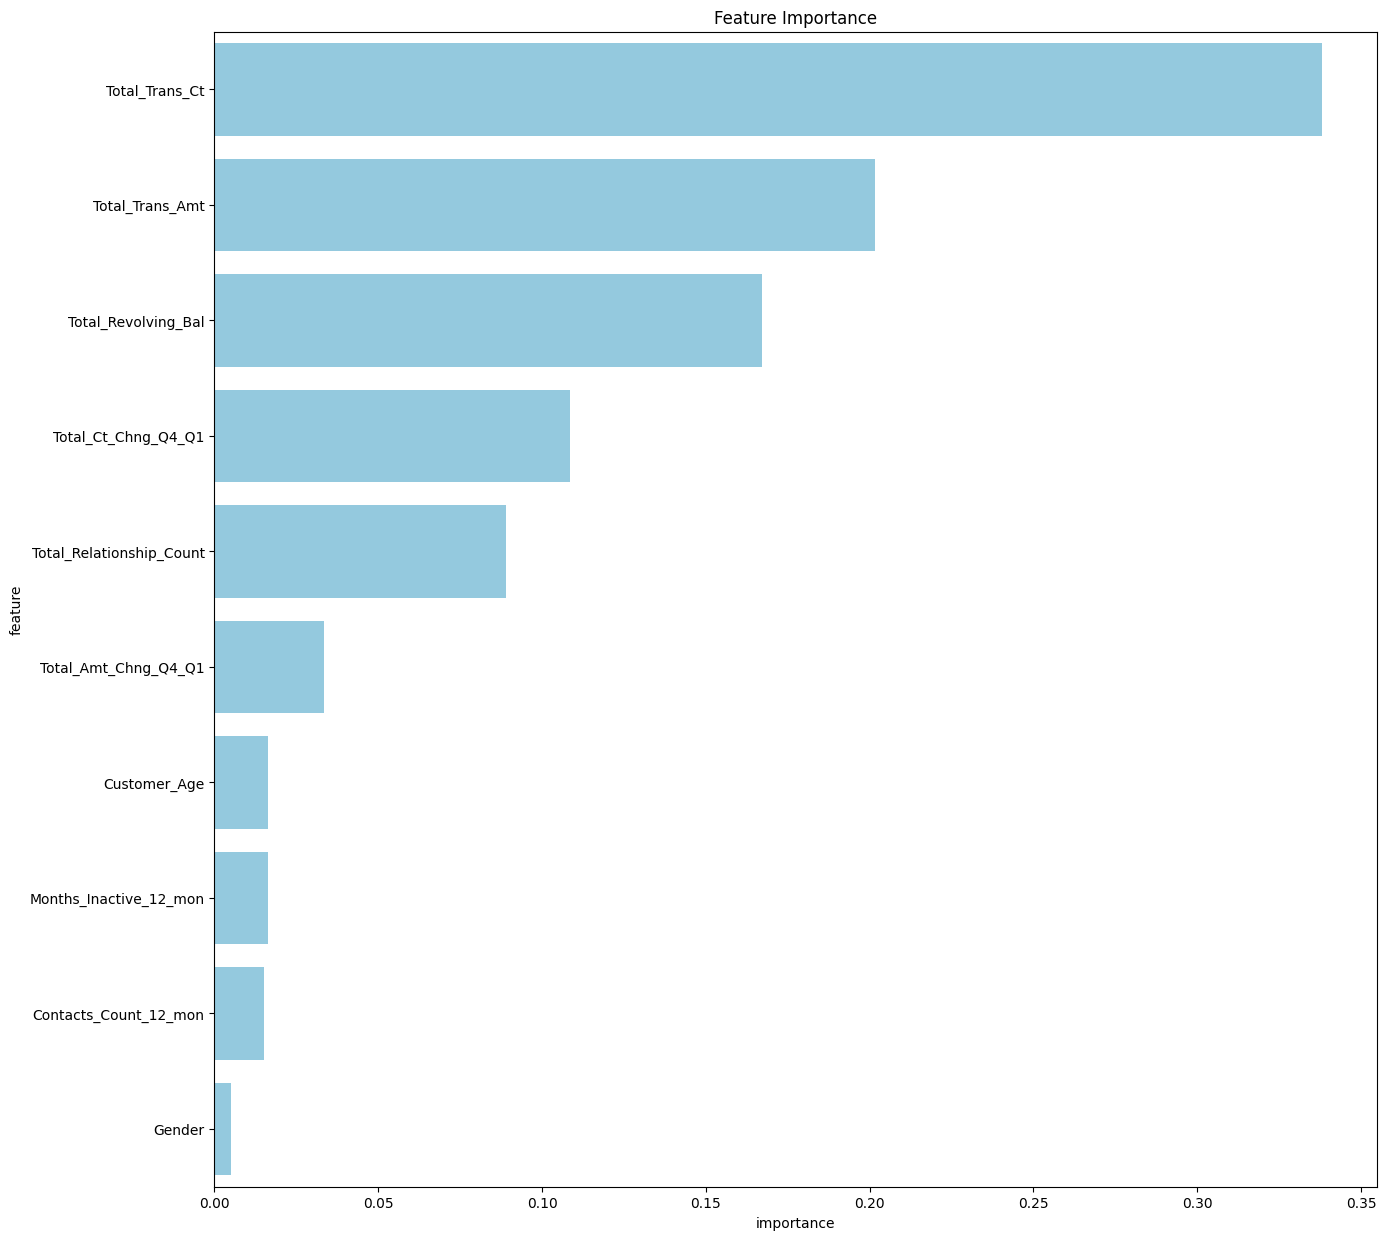

,feature,importance
0,Total_Trans_Ct,0.337940
1,Total_Trans_Amt,0.201604
2,Total_Revolving_Bal,0.167296
3,Total_Ct_Chng_Q4_Q1,0.108446
4,Total_Relationship_Count,0.088922
5,Total_Amt_Chng_Q4_Q1,0.033510
6,Customer_Age,0.016503
7,Months_Inactive_12_mon,0.016366
8,Contacts_Count_12_mon,0.015187
9,Gender,0.005031


In [148]:
# Call the function to plot and return the top 10 important features
feature_importance(Model_GradientBoostingClassifier, X_train)

Data rebalancing using SMOTE, ADASYN, RandomUnderSampler, SMOTEEN, and SMOTETomek.
I increased the data, a technique normally discouraged, by duplicating samples from the target class 0.
I used an ensemble method with BalancedBagging.
NearMiss.
Experiments were done generating new variables such as: Average_Transaction_Amount, Transaction_Frequency, Average_Transaction_Balance, Percent_Change_Transaction_Amount, Transaction_Frequency, Average_Transaction_Duration.
I tried to reduce noise in class 0 by removing more data. The goal was to reduce the differences in numerical variable values in the multivariable analysis so the model would focus on predicting 0 if a certain series of events occurred, without hesitation. The cleaned variables were: Total_Revolving_Bal, Total_Trans_Amt, Total_Trans_Ct, Total_Ct_Chng_Q4_Q1.
I tried building the model using only important variables, but the best performance was 0.90.
I also tried creating two clusters of clients, but the model performance was slightly worse, from 0.932 to 0.939.

# f1
The F1-score metric is useful when we have class imbalance, that is, when one class appears much more frequently than another. In these cases, Accuracy can give a false impression of good performance.

In [149]:

from utils import data_report, EDA

In [150]:
data_report(df_train)

Información general:

<class 'pandas.DataFrame'>
RangeIndex: 8101 entries, 0 to 8100
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   train_idx                 8101 non-null   int64  
 1   CLIENTNUM                 8101 non-null   int64  
 2   Customer_Age              8101 non-null   int64  
 3   Gender                    8101 non-null   str    
 4   Dependent_count           8101 non-null   int64  
 5   Education_Level           8101 non-null   str    
 6   Marital_Status            8101 non-null   str    
 7   Income_Category           8101 non-null   str    
 8   Card_Category             8101 non-null   str    
 9   Months_on_book            8101 non-null   int64  
 10  Total_Relationship_Count  8101 non-null   int64  
 11  Months_Inactive_12_mon    8101 non-null   int64  
 12  Contacts_Count_12_mon     8101 non-null   int64  
 13  Credit_Limit              8101 non-null   float64
 1